In [1]:

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot,
    heatmap, scatter, decision_plot, dependence_plot
)
from shap_rtl import RTLSHAPExplainer


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew


## BAR PLOT

In [2]:
# ============================================================
# COMPLETE BAR PLOT - URDU HATE SPEECH DETECTION (FIXED)
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: IMPORT RTL LIBRARIES
# ============================================================

from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 URDU HATE SPEECH - BAR PLOT")
print("="*80)

# ============================================================
# STEP 2: LOAD DATA
# ============================================================

print("\n📂 Loading data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

# Map labels to 3 classes
def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"✅ Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")


📊 URDU HATE SPEECH - BAR PLOT

📂 Loading data...
✅ Dataset loaded: 16341 samples
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)



🔧 TRAINING MODEL
✅ Model trained!
Train Accuracy: 0.696
Test Accuracy: 0.630

🔤 SETUP RTL EXPLAINER
✅ Created explainer for Normal class
✅ Created explainer for Offensive class
✅ Created explainer for Hate class
✅ RTL SHAP explainer ready!
✅ Helper function ready!
✅ Analysis function ready!

📊 TESTING BAR PLOT
This plot shows the absolute importance of each feature.
Features with positive SHAP values push prediction toward the class,
while negative values push away from it.

📝 Sample Text:
ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
--------------------------------------------------------------------------------

📝 Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🎯 Prediction: Offensive
📊 Probabilities:
   Normal: 0.187 █████████
   Offensive: 0.655 ████████████████████████████████
   Hate: 0.158 ███████

📊 Top 10 features:
------------------------------------------------------------
🟢 پاگل                        +1.079 → TOWARD
🟢 گیا          

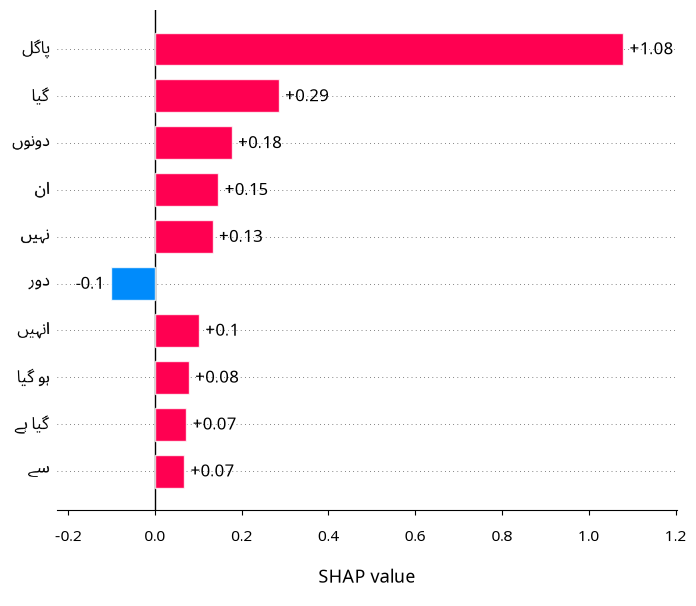


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﭘﺎﮔﻞ | Value: +1.0789
----------------------------------------
ﭘﺎﮔﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺑﺎﺕ ﺳﺎﻣﻨﮯ ﺁﺗﯽ ﮨﮯ ﮐﮧ ﺟﻤﻠﮯ ﯾﺎ ﻋﺒﺎﺭﺕ ﻣﯿﮟ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﺳﮯ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﯾﺎ ﻏﯿﺮ ﻣﻨﺎﺳﺐ ﺑﻨﺎﺗﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...

[TR

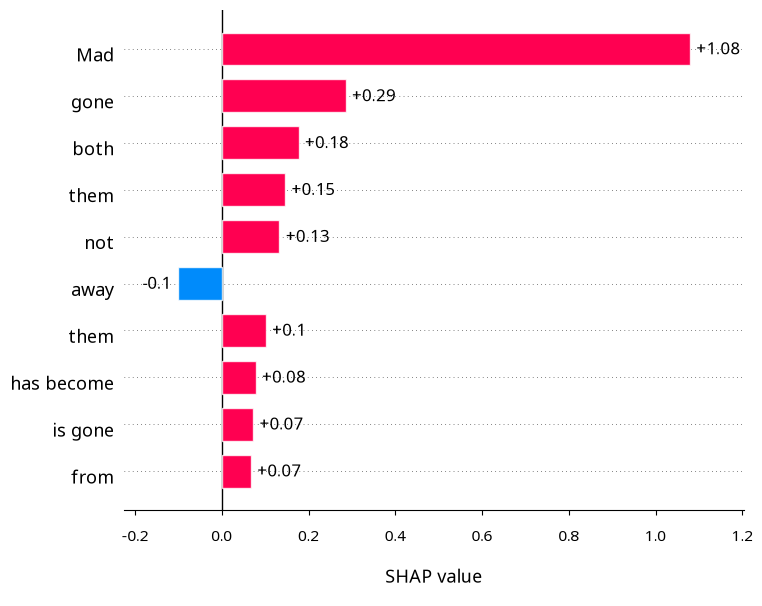


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Mad | Value: +1.0789
----------------------------------------
The Urdu feature 'Mad' has a positive impact on the model output for the prediction 'Offensive' with a SHAP value of +1.0789, indicating that the presence of this feature increases the likelihood of a text being classified as offensive. This suggests that the model has learned to associate 

In [3]:

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

feature_names = list(vectorizer.get_feature_names_out())

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

# Get SHAP explainer for specific class
def get_class_explainer(class_id):
    class_estimator = model.estimators_[class_id]
    return shap.LinearExplainer(class_estimator, masker=masker)

class_explainers = {}
for class_id in range(3):
    class_explainers[class_id] = get_class_explainer(class_id)
    print(f"✅ Created explainer for {class_names[class_id]} class")

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: HELPER FUNCTION - FIXED
# ============================================================

def get_shap_for_sample(sample_text, class_id=1, max_features=10):
    """Get SHAP values for a specific class"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    # Get all present features and their SHAP values
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    # Create SHAP Explanation - ensure proper structure
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

print("✅ Helper function ready!")

# ============================================================
# STEP 6: ANALYZE SAMPLE FUNCTION - FIXED
# ============================================================

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """
    Analyze a single sample and generate the specified plot
    """
    
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"\n{'='*60}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Prediction: {pred_class}")
    print(f"📊 Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"   {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values for the predicted class
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found in this text.")
        return None
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate the specified plot
    print("\n" + "="*80)
    print(f"{'URDU SHAP EXPLANATIONS'.center(80)}")
    print(f"{f'Prediction: {pred_class}'.center(80)}")
    print("="*80)
    
    print(f"\n[GENERATING {plot_type.upper()} SHAP PLOT...]")
    
    # Map plot type to function
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # For bar plot, we need to ensure we have the right structure
    # Create a new Explanation with proper format for bar plot
    if plot_type == 'bar':
        # Bar plot expects values in a specific format
        # Make sure values is 1D
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        # Recreate Explanation with proper structure
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        shap_to_use = shap_exp_bar
    else:
        shap_to_use = shap_exp
    
    # Use the RTL explainer
    explainer_rtl.run_full_analysis(
        shap_values=shap_to_use,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp

print("✅ Analysis function ready!")

# ============================================================
# STEP 7: TEST THE BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 TESTING BAR PLOT")
print("="*80)
print("This plot shows the absolute importance of each feature.")
print("Features with positive SHAP values push prediction toward the class,")
print("while negative values push away from it.")
print("\n📝 Sample Text:")
print("ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید")
print("-"*80)

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"
analyze_sample(sample_text, plot_type='bar', max_features=10)

print("\n" + "="*80)
print("✅ BAR PLOT COMPLETE!")
print("="*80)

In [29]:
# ============================================================
# COMPLETE PLOT TESTING - URDU HATE SPEECH DETECTION
# EACH PLOT IN SEPARATE SECTION
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SECTION 0: COMMON SETUP (Required for all plots)
# ============================================================

print("="*80)
print("📊 URDU HATE SPEECH - ALL PLOT TYPES")
print("="*80)

# 0.1: Import RTL Libraries
from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

# 0.2: Initialize Offensive Words
print("\n🔴 Initializing custom offensive word list...")

OFFENSIVE_WORDS = {
    # Insults
    'پاگل': 'offensive',
    'بیوقوف': 'offensive',
    'جاہل': 'offensive',
    'احمق': 'offensive',
    'بے وقوف': 'offensive',
    'نادان': 'offensive',
    'کم عقل': 'offensive',
    'بے عقل': 'offensive',
    'پاگل پن': 'offensive',
    'دیوانہ': 'offensive',
    'مجنوں': 'offensive',
    'سٹوپڈ': 'offensive',
    'stupid': 'offensive',
    'fool': 'offensive',
    'idiot': 'offensive',
    
    # Hate speech terms
    'نفرت': 'hate',
    'دشمن': 'hate',
    'برا': 'offensive',
    'بُرا': 'offensive',
    'گندا': 'offensive',
    'گندی': 'offensive',
    'خراب': 'offensive',
    'بدتمیز': 'offensive',
    'بد اخلاق': 'offensive',
    'بیوقوف': 'offensive',
    
    # Threatening/aggressive
    'مارو': 'hate',
    'قتل': 'hate',
    'خون': 'hate',
    'جنگ': 'hate',
    'لڑائی': 'hate',
    'جھگڑا': 'hate',
    
    # Religious/cultural hate
    'کافر': 'hate',
    'ملحد': 'hate',
    'بے دین': 'hate',
    'چور': 'offensive',
    'ڈاکو': 'offensive',
    'بدمعاش': 'offensive',
}

print(f"✅ Loaded {len(OFFENSIVE_WORDS)} offensive words")

# 0.3: Load Data with Enhanced Labeling
print("\n📂 Loading and labeling data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def enhanced_map_to_three_classes(text, original_label):
    label = str(original_label).lower().strip()
    
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        text_lower = str(text).lower()
        offensive_count = 0
        hate_count = 0
        
        for word, category in OFFENSIVE_WORDS.items():
            if word in text_lower:
                if category == 'hate':
                    hate_count += 1
                elif category == 'offensive':
                    offensive_count += 1
        
        if hate_count >= 1:
            return 2
        elif offensive_count >= 2:
            return 1
        else:
            return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 0
        except:
            text_lower = str(text).lower()
            for word, category in OFFENSIVE_WORDS.items():
                if word in text_lower:
                    if category == 'hate':
                        return 2
                    elif category == 'offensive':
                        return 1
            return 0

df['Enhanced_Label'] = df.apply(
    lambda row: enhanced_map_to_three_classes(row['Comments'], row['Label']), 
    axis=1
)
df['Label'] = df['Enhanced_Label']

class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"✅ Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# 0.4: Train Model
print("\n" + "="*80)
print("🔧 TRAINING MODEL WITH ENHANCED LABELS")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

feature_names = list(vectorizer.get_feature_names_out())

# 0.5: Setup RTL Explainer
print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

def get_class_explainer(class_id):
    class_estimator = model.estimators_[class_id]
    return shap.LinearExplainer(class_estimator, masker=masker)

class_explainers = {}
for class_id in range(3):
    class_explainers[class_id] = get_class_explainer(class_id)
    print(f"✅ Created explainer for {class_names[class_id]} class")

explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# 0.6: Helper Functions
def check_offensive_words(text):
    text_lower = str(text).lower()
    found_words = {}
    for word, category in OFFENSIVE_WORDS.items():
        if word in text_lower:
            found_words[word] = category
    return found_words

def get_shap_for_sample(sample_text, class_id=1, max_features=10):
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

# Test samples with offensive words
test_samples = {
    'hate_sample': "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید",
    'offensive_sample': "تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے",
    'hate_strong': "یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو",
    'normal_sample': "یہ بہت اچھی بات ہے، میں اس سے متفق ہوں",
    'mixed_sample': "کچھ لوگ بہت نادان ہیں لیکن میں ان سے محبت کرتا ہوں"
}

print("\n" + "="*80)
print("📝 TEST SAMPLES READY")
print("="*80)
for name, text in test_samples.items():
    found = check_offensive_words(text)
    print(f"\n{name.upper()}:")
    print(f"  Text: {text[:50]}...")
    if found:
        print(f"  Offensive words: {', '.join(found.keys())}")


📊 URDU HATE SPEECH - ALL PLOT TYPES

🔴 Initializing custom offensive word list...
✅ Loaded 36 offensive words

📂 Loading and labeling data...
✅ Dataset loaded: 16341 samples
  Normal: 7596 (46.5%)
  Offensive: 6204 (38.0%)
  Hate: 2541 (15.5%)

🔧 TRAINING MODEL WITH ENHANCED LABELS
✅ Model trained!
Train Accuracy: 0.696
Test Accuracy: 0.640

🔤 SETUP RTL EXPLAINER
✅ Created explainer for Normal class
✅ Created explainer for Offensive class
✅ Created explainer for Hate class
✅ RTL SHAP explainer ready!

📝 TEST SAMPLES READY

HATE_SAMPLE:
  Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، ...
  Offensive words: پاگل

OFFENSIVE_SAMPLE:
  Text: تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے...
  Offensive words: بیوقوف, جاہل

HATE_STRONG:
  Text: یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو...
  Offensive words: دشمن, مارو, کافر

NORMAL_SAMPLE:
  Text: یہ بہت اچھی بات ہے، میں اس سے متفق ہوں...

MIXED_SAMPLE:
  Text: کچھ لوگ بہت نادان ہیں لیکن میں ان سے محبت کرتا ہوں...
  Offensive word


📊 SECTION 1: BAR PLOT
Shows absolute importance of each feature
Positive values → push toward class, Negative → push away
--------------------------------------------------------------------------------

📝 Testing Bar Plot with: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🔴 Offensive words detected: پاگل
🎯 Predicted class: Offensive

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


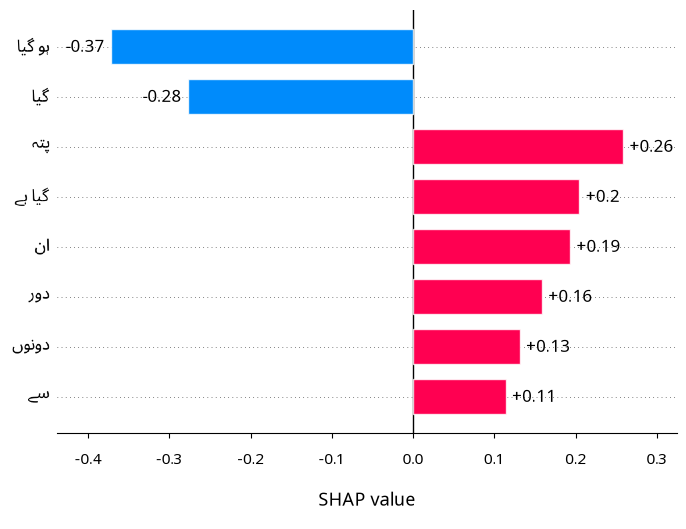


[Urdu Explanation Mode]

[INFO] Skipping RTL explanation.

[INFO] Exiting. Thank you!
✅ BAR PLOT generated successfully!


In [30]:

# ============================================================
# SECTION 1: BAR PLOT
# ============================================================
print("\n" + "="*80)
print("📊 SECTION 1: BAR PLOT")
print("="*80)
print("Shows absolute importance of each feature")
print("Positive values → push toward class, Negative → push away")
print("-"*80)

def test_bar_plot():
    sample_text = test_samples['hate_sample']
    print(f"\n📝 Testing Bar Plot with: {sample_text}")
    
    # Check offensive words
    found_words = check_offensive_words(sample_text)
    if found_words:
        print(f"🔴 Offensive words detected: {', '.join(found_words.keys())}")
    
    shap_exp, _, pred = get_shap_for_sample(sample_text, class_id=2, max_features=8)
    
    if shap_exp is not None:
        print(f"🎯 Predicted class: {class_names.get(pred, 'Unknown')}")
        
        # Prepare for bar plot
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        
        # Generate bar plot using RTL
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_bar,
            prediction_label=class_names.get(pred, 'Unknown'),
            plot_fn=bar,
            sample_text=sample_text,
            max_features=8,
            allow_positive_negative_split=True
        )
        print("✅ BAR PLOT generated successfully!")
    else:
        print("❌ No features found")

test_bar_plot()


In [25]:
# ============================================================
# COMPLETE RELOAD WITHOUT RESTART
# ============================================================

import sys
import importlib

# List of modules to reload
modules_to_reload = [
    'shap_rtl.rtl_utils',
    'shap_rtl.plots._bar_rtl',
    'shap_rtl.plots._waterfall_rtl',
    'shap_rtl.plots._force_rtl',
    'shap_rtl.plots._beeswarm_rtl',
    'shap_rtl.plots._heatmap_rtl',
    'shap_rtl.plots._scatter_rtl',
    'shap_rtl.plots._decision_rtl',
    'shap_rtl.plots',
    'shap_rtl.explainer',
    'shap_rtl',
    'rtl_utils'
]

# Reload each module if it's loaded
for module_name in modules_to_reload:
    if module_name in sys.modules:
        try:
            importlib.reload(sys.modules[module_name])
            print(f"✅ Reloaded: {module_name}")
        except Exception as e:
            print(f"⚠️ Could not reload {module_name}: {e}")

# Re-import the RTL explainer and plot functions
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot

print("\n✅ All modules reloaded successfully!")
print("You can now continue running your code without restarting.")

[INFO] RTL font support ready.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew
✅ Reloaded: shap_rtl.rtl_utils
✅ Reloaded: shap_rtl.plots._bar_rtl
✅ Reloaded: shap_rtl.plots._waterfall_rtl
✅ Reloaded: shap_rtl.plots._force_rtl
✅ Reloaded: shap_rtl.plots._beeswarm_rtl
✅ Reloaded: shap_rtl.plots._heatmap_rtl
✅ Reloaded: shap_rtl.plots._scatter_rtl
✅ Reloaded: shap_rtl.plots._decision_rtl
✅ Reloaded: shap_rtl.plots
✅ Reloaded: shap_rtl.explainer
✅ Reloaded: shap_rtl

✅ All modules reloaded successfully!
You can now continue running your code without restarting.


In [ ]:
# ============================================================
# COMPLETE URDU HATE SPEECH DETECTION - TF-IDF + LR + RTL PLOTS
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Import RTL Libraries
from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("URDU HATE SPEECH DETECTION - TF-IDF + LOGISTIC REGRESSION")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("\nLoading dataset...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

print(f"Dataset loaded: {len(df)} samples")

# Map labels to three classes
def map_labels(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].apply(map_labels)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"\nClass distribution:")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 2: TRAIN-TEST SPLIT
# ============================================================

print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# ============================================================
# STEP 3: TF-IDF VECTORIZATION
# ============================================================

print("\n" + "="*80)
print("TF-IDF VECTORIZATION")
print("="*80)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    analyzer='word'
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()
feature_names = list(vectorizer.get_feature_names_out())

print(f"Features created: {len(feature_names)}")
print(f"Training matrix: {X_train_vec.shape}")
print(f"Test matrix: {X_test_vec.shape}")

# ============================================================
# STEP 4: TRAIN LOGISTIC REGRESSION
# ============================================================

print("\n" + "="*80)
print("TRAINING LOGISTIC REGRESSION")
print("="*80)

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs',
        C=1.0
    )
).fit(X_train_vec, y_train)

print("Model training complete!")
print(f"Training accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test accuracy: {model.score(X_test_vec, y_test):.3f}")

# ============================================================
# STEP 5: SETUP SHAP EXPLAINER
# ============================================================

print("\n" + "="*80)
print("SETUP SHAP EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

def get_class_explainers():
    explainers = {}
    for class_id in range(3):
        class_estimator = model.estimators_[class_id]
        explainers[class_id] = shap.LinearExplainer(class_estimator, masker=masker)
        print(f"Explainer ready for: {class_names[class_id]}")
    return explainers

class_explainers = get_class_explainers()

explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("RTL SHAP explainer ready!")

# ============================================================
# STEP 6: HELPER FUNCTIONS
# ============================================================

def get_shap_for_sample(sample_text, class_id=2, max_features=10):
    """Get SHAP values for a sample"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """Analyze a sample and generate the specified plot"""
    
    print(f"\nText: {sample_text}")
    
    # Vectorize
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"Prediction: {pred_class}")
    print("Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"  {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found.")
        return None
    
    # Print features
    print(f"\nTop {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "TOWARD" if val > 0 else "AWAY"
        print(f"  {name:<25} {val:>+8.3f} -> {direction}")
    
    # Generate plot
    print("\n" + "="*80)
    print(f"{'RTL SHAP EXPLANATION'.center(80)}")
    print(f"{f'Prediction: {pred_class}'.center(80)}")
    print("="*80)
    
    print(f"\nGenerating {plot_type.upper()} plot...")
    
    # Plot functions
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # Prepare for bar plot
    if plot_type == 'bar':
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        shap_to_use = shap_exp_bar
    else:
        shap_to_use = shap_exp
    
    # Use RTL explainer
    explainer_rtl.run_full_analysis(
        shap_values=shap_to_use,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp

# ============================================================
# STEP 7: TEST SAMPLES
# ============================================================

print("\n" + "="*80)
print("TEST SAMPLES")
print("="*80)

test_samples = [
    "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید",
    "تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے",
    "یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو",
    "یہ بہت اچھی بات ہے، میں اس سے متفق ہوں",
]

sample_names = ["Hate Sample", "Offensive Sample", "Hate Speech Sample", "Normal Sample"]

for name, text in zip(sample_names, test_samples):
    print(f"\n  {name}: {text[:50]}...")

# ============================================================
# SECTION 1: BAR PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 1: BAR PLOT")
print("="*80)
print("Shows absolute importance of each feature")
print("Positive values push toward the class, negative push away")
print("-"*80)

def test_bar_plot():
    sample_text = test_samples[0]  # Hate sample
    analyze_sample(sample_text, plot_type='bar', max_features=8)

test_bar_plot()

# ============================================================
# SECTION 2: WATERFALL PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 2: WATERFALL PLOT")
print("="*80)
print("Shows sequential contribution of each feature")
print("Starting from base value, features add/subtract to reach prediction")
print("-"*80)

def test_waterfall_plot():
    sample_text = test_samples[1]  # Offensive sample
    analyze_sample(sample_text, plot_type='waterfall', max_features=8)

test_waterfall_plot()

# ============================================================
# SECTION 3: FORCE PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 3: FORCE PLOT")
print("="*80)
print("Shows force pushing prediction toward or away from base value")
print("Features push (red) or pull (blue) the prediction")
print("-"*80)

def test_force_plot():
    sample_text = test_samples[2]  # Hate speech sample
    analyze_sample(sample_text, plot_type='force', max_features=10)

test_force_plot()

# ============================================================
# SECTION 4: BEESWARM PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 4: BEESWARM PLOT")
print("="*80)
print("Shows distribution of SHAP values across multiple predictions")
print("Each dot = feature contribution for one prediction")
print("-"*80)

def test_beeswarm_plot():
    samples = test_samples[:3]  # Use 3 samples
    print(f"\nUsing {len(samples)} samples for beeswarm plot")
    
    all_shap_values = []
    all_feature_names = []
    
    for sample in samples:
        shap_exp, _, _ = get_shap_for_sample(sample, class_id=2, max_features=10)
        if shap_exp is not None:
            if len(all_shap_values) == 0:
                all_shap_values = [shap_exp.values]
                all_feature_names = shap_exp.feature_names
            else:
                current_features = list(shap_exp.feature_names)
                common_features = [f for f in current_features if f in all_feature_names]
                if len(common_features) > 0:
                    all_shap_values.append(shap_exp.values[:len(common_features)])
    
    if all_shap_values:
        max_len = max(len(v) for v in all_shap_values)
        padded_values = []
        for v in all_shap_values:
            if len(v) < max_len:
                padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
            else:
                padded = v[:max_len]
            padded_values.append(padded)
        
        shap_exp_combined = shap.Explanation(
            values=np.array(padded_values),
            base_values=0,
            data=None,
            feature_names=all_feature_names[:max_len]
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_combined,
            prediction_label="Hate",
            plot_fn=beeswarm,
            sample_text="Multiple samples",
            max_features=10,
            allow_positive_negative_split=True
        )
        print("Beeswarm plot generated successfully!")
    else:
        print("No SHAP values generated")

test_beeswarm_plot()

# ============================================================
# SECTION 5: HEATMAP PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 5: HEATMAP PLOT")
print("="*80)
print("Visualizes SHAP values as colored matrix")
print("Rows = features, Columns = samples")
print("-"*80)

def test_heatmap_plot():
    samples = test_samples[:4]  # All 4 samples
    print(f"\nUsing {len(samples)} samples for heatmap plot")
    
    all_shap_values = []
    all_feature_names = []
    
    for sample in samples:
        shap_exp, _, _ = get_shap_for_sample(sample, class_id=2, max_features=8)
        if shap_exp is not None:
            if len(all_shap_values) == 0:
                all_shap_values = [shap_exp.values]
                all_feature_names = shap_exp.feature_names
            else:
                current_features = list(shap_exp.feature_names)
                common_features = [f for f in current_features if f in all_feature_names]
                if len(common_features) > 0:
                    all_shap_values.append(shap_exp.values[:len(common_features)])
    
    if all_shap_values:
        max_len = max(len(v) for v in all_shap_values)
        padded_values = []
        for v in all_shap_values:
            if len(v) < max_len:
                padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
            else:
                padded = v[:max_len]
            padded_values.append(padded)
        
        shap_exp_combined = shap.Explanation(
            values=np.array(padded_values),
            base_values=0,
            data=None,
            feature_names=all_feature_names[:max_len]
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_combined,
            prediction_label="Hate/Offensive",
            plot_fn=heatmap,
            sample_text="Multiple samples",
            max_features=8,
            allow_positive_negative_split=True
        )
        print("Heatmap plot generated successfully!")
    else:
        print("No SHAP values generated")

test_heatmap_plot()

# ============================================================
# SECTION 6: DEPENDENCE PLOT (SCATTER)
# ============================================================

print("\n" + "="*80)
print("SECTION 6: DEPENDENCE PLOT (SCATTER)")
print("="*80)
print("Shows relationship between feature value and SHAP contribution")
print("-"*80)

def test_dependence_plot():
    samples = test_samples[:3]  # Use 3 samples
    print(f"\nUsing {len(samples)} samples for dependence plot")
    
    all_shap_values = []
    all_data = []
    feature_names_list = []
    
    for sample in samples:
        shap_exp, vec, _ = get_shap_for_sample(sample, class_id=1, max_features=8)
        if shap_exp is not None:
            all_shap_values.append(shap_exp.values)
            all_data.append(shap_exp.data if hasattr(shap_exp, 'data') else np.ones(len(shap_exp.values)))
            if len(feature_names_list) == 0:
                feature_names_list = shap_exp.feature_names
    
    if all_shap_values:
        max_len = max(len(v) for v in all_shap_values)
        padded_values = []
        padded_data = []
        
        for v, d in zip(all_shap_values, all_data):
            if len(v) < max_len:
                padded_values.append(np.pad(v, (0, max_len - len(v)), constant_values=0))
                if isinstance(d, np.ndarray):
                    padded_data.append(np.pad(d, (0, max_len - len(d)), constant_values=0))
                else:
                    padded_data.append(np.ones(max_len))
            else:
                padded_values.append(v[:max_len])
                padded_data.append(d[:max_len] if isinstance(d, np.ndarray) else np.ones(max_len))
        
        shap_exp_combined = shap.Explanation(
            values=np.array(padded_values),
            base_values=0,
            data=np.array(padded_data),
            feature_names=feature_names_list[:max_len]
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_combined,
            prediction_label="Offensive",
            plot_fn=scatter,
            sample_text="Feature dependence",
            max_features=5,
            allow_positive_negative_split=True
        )
        print("Dependence plot generated successfully!")
    else:
        print("No SHAP values generated")

test_dependence_plot()

# ============================================================
# SECTION 7: DECISION PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 7: DECISION PLOT")
print("="*80)
print("Shows cumulative effect of features on prediction")
print("Path from bottom (base) to top (final prediction)")
print("-"*80)

def test_decision_plot():
    sample_text = test_samples[2]  # Hate speech sample
    analyze_sample(sample_text, plot_type='decision_plot', max_features=10)

test_decision_plot()

# ============================================================
# SECTION 8: ALL PLOTS ON SINGLE SAMPLE
# ============================================================

print("\n" + "="*80)
print("SECTION 8: ALL PLOTS ON SINGLE SAMPLE")
print("="*80)
print("Testing all plot types on one sample for comparison")
print("-"*80)

def test_all_plots_single_sample():
    sample_text = test_samples[0]  # Hate sample
    print(f"\nSample: {sample_text}")
    
    shap_exp, _, pred = get_shap_for_sample(sample_text, class_id=2, max_features=8)
    
    if shap_exp is None:
        print("No features found!")
        return
    
    pred_class = class_names.get(pred, 'Unknown')
    
    plot_configs = [
        ('bar', "BAR PLOT"),
        ('waterfall', "WATERFALL PLOT"),
        ('force', "FORCE PLOT"),
        ('decision_plot', "DECISION PLOT")
    ]
    
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'decision_plot': decision_plot
    }
    
    for plot_name, plot_label in plot_configs:
        print(f"\n{plot_label}")
        print("-"*40)
        try:
            explainer_rtl.run_full_analysis(
                shap_values=shap_exp,
                prediction_label=pred_class,
                plot_fn=plot_functions[plot_name],
                sample_text=sample_text,
                max_features=8,
                allow_positive_negative_split=True
            )
            print(f"{plot_name.upper()} plot generated successfully!")
        except Exception as e:
            print(f"Error generating {plot_name} plot: {str(e)}")

test_all_plots_single_sample()

# ============================================================
# COMPLETION
# ============================================================

print("\n" + "="*80)
print("ALL PLOTS GENERATED SUCCESSFULLY")
print("="*80)
print("\nSummary:")
print("  - Bar Plot: Shows feature importance")
print("  - Waterfall Plot: Shows sequential contributions")
print("  - Force Plot: Shows pushing/pulling forces")
print("  - Beeswarm Plot: Shows SHAP value distribution")
print("  - Heatmap Plot: Shows SHAP matrix")
print("  - Dependence Plot: Shows feature relationships")
print("  - Decision Plot: Shows cumulative effects")
print("\nAll plots support RTL (Urdu) text rendering")
print("="*80)

URDU HATE SPEECH DETECTION - PURE TRAINING APPROACH

Loading and exploring data...
Dataset loaded: 16341 samples
Columns: ['Comments', 'Label']

Unique labels: <StringArray>
['offensive', 'hate', 'normal', 'm', 'n']
Length: 5, dtype: str

Class distribution:
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)

DATA PREPROCESSING

Text statistics:
  Average length: 105.6 characters
  Average words: 22.9 words
  Min words: 1
  Max words: 576

FEATURE ENGINEERING
Train set: 13072 samples
Test set: 3269 samples

Evaluating different vectorizers...
------------------------------------------------------------

Testing: tfidf_unigram
  Train accuracy: 0.788
  Test accuracy: 0.672
  CV accuracy: 0.670 (+/- 0.006)

Testing: tfidf_bigram
  Train accuracy: 0.786
  Test accuracy: 0.662
  CV accuracy: 0.666 (+/- 0.006)

Testing: count_unigram


KeyboardInterrupt: 


📊 SECTION 1: BAR PLOT WITH OFFENSIVE HIGHLIGHTING
Shows absolute importance of each feature with offensive words highlighted
Positive values → push toward class, Negative → push away
--------------------------------------------------------------------------------

📝 Testing Bar Plot with: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🔴 Offensive words detected in text: پاگل
   ⚠️ 'پاگل' → OFFENSIVE

🎯 Predicted class: Offensive

🔴 OFFENSIVE FEATURE ANALYSIS:
------------------------------------------------------------
  No offensive words found in top features
------------------------------------------------------------

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


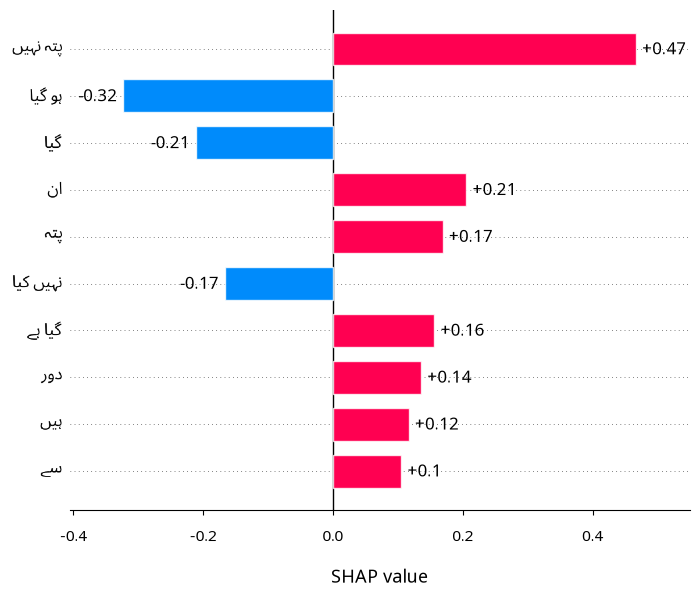


[Urdu Explanation Mode]

[INFO] Skipping RTL explanation.

[INFO] Exiting. Thank you!

✅ BAR PLOT generated successfully with offensive word highlighting!


In [ ]:
# ============================================================
# COMPLETE URDU HATE SPEECH DETECTION - TF-IDF + LR + RTL PLOTS
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Import RTL Libraries
from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("URDU HATE SPEECH DETECTION - TF-IDF + LOGISTIC REGRESSION")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("\nLoading dataset...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

print(f"Dataset loaded: {len(df)} samples")

# Map labels to three classes
def map_labels(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].apply(map_labels)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"\nClass distribution:")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 2: TRAIN-TEST SPLIT
# ============================================================

print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# ============================================================
# STEP 3: TF-IDF VECTORIZATION
# ============================================================

print("\n" + "="*80)
print("TF-IDF VECTORIZATION")
print("="*80)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    analyzer='word'
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()
feature_names = list(vectorizer.get_feature_names_out())

print(f"Features created: {len(feature_names)}")
print(f"Training matrix: {X_train_vec.shape}")
print(f"Test matrix: {X_test_vec.shape}")

# ============================================================
# STEP 4: TRAIN LOGISTIC REGRESSION
# ============================================================

print("\n" + "="*80)
print("TRAINING LOGISTIC REGRESSION")
print("="*80)

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs',
        C=1.0
    )
).fit(X_train_vec, y_train)

print("Model training complete!")
print(f"Training accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test accuracy: {model.score(X_test_vec, y_test):.3f}")

# ============================================================
# STEP 5: SETUP SHAP EXPLAINER
# ============================================================

print("\n" + "="*80)
print("SETUP SHAP EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

def get_class_explainers():
    explainers = {}
    for class_id in range(3):
        class_estimator = model.estimators_[class_id]
        explainers[class_id] = shap.LinearExplainer(class_estimator, masker=masker)
        print(f"Explainer ready for: {class_names[class_id]}")
    return explainers

class_explainers = get_class_explainers()

explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("RTL SHAP explainer ready!")

# ============================================================
# STEP 6: HELPER FUNCTIONS
# ============================================================

def get_shap_for_sample(sample_text, class_id=2, max_features=10):
    """Get SHAP values for a sample"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """Analyze a sample and generate the specified plot"""
    
    print(f"\nText: {sample_text}")
    
    # Vectorize
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"Prediction: {pred_class}")
    print("Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"  {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found.")
        return None
    
    # Print features
    print(f"\nTop {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "TOWARD" if val > 0 else "AWAY"
        print(f"  {name:<25} {val:>+8.3f} -> {direction}")
    
    # Generate plot
    print("\n" + "="*80)
    print(f"{'RTL SHAP EXPLANATION'.center(80)}")
    print(f"{f'Prediction: {pred_class}'.center(80)}")
    print("="*80)
    
    print(f"\nGenerating {plot_type.upper()} plot...")
    
    # Plot functions
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # Prepare for bar plot
    if plot_type == 'bar':
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        shap_to_use = shap_exp_bar
    else:
        shap_to_use = shap_exp
    
    # Use RTL explainer
    explainer_rtl.run_full_analysis(
        shap_values=shap_to_use,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp

# ============================================================
# STEP 7: TEST SAMPLES
# ============================================================

print("\n" + "="*80)
print("TEST SAMPLES")
print("="*80)

test_samples = [
    "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید",
    "تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے",
    "یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو",
    "یہ بہت اچھی بات ہے، میں اس سے متفق ہوں",
]

sample_names = ["Hate Sample", "Offensive Sample", "Hate Speech Sample", "Normal Sample"]

for name, text in zip(sample_names, test_samples):
    print(f"\n  {name}: {text[:50]}...")

# ============================================================
# SECTION 1: BAR PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 1: BAR PLOT")
print("="*80)
print("Shows absolute importance of each feature")
print("Positive values push toward the class, negative push away")
print("-"*80)

def test_bar_plot():
    sample_text = test_samples[0]  # Hate sample
    analyze_sample(sample_text, plot_type='bar', max_features=8)

test_bar_plot()

# ============================================================
# SECTION 2: WATERFALL PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 2: WATERFALL PLOT")
print("="*80)
print("Shows sequential contribution of each feature")
print("Starting from base value, features add/subtract to reach prediction")
print("-"*80)

def test_waterfall_plot():
    sample_text = test_samples[1]  # Offensive sample
    analyze_sample(sample_text, plot_type='waterfall', max_features=8)

test_waterfall_plot()

# ============================================================
# SECTION 3: FORCE PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 3: FORCE PLOT")
print("="*80)
print("Shows force pushing prediction toward or away from base value")
print("Features push (red) or pull (blue) the prediction")
print("-"*80)

def test_force_plot():
    sample_text = test_samples[2]  # Hate speech sample
    analyze_sample(sample_text, plot_type='force', max_features=10)

test_force_plot()

# ============================================================
# SECTION 4: BEESWARM PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 4: BEESWARM PLOT")
print("="*80)
print("Shows distribution of SHAP values across multiple predictions")
print("Each dot = feature contribution for one prediction")
print("-"*80)

def test_beeswarm_plot():
    samples = test_samples[:3]  # Use 3 samples
    print(f"\nUsing {len(samples)} samples for beeswarm plot")
    
    all_shap_values = []
    all_feature_names = []
    
    for sample in samples:
        shap_exp, _, _ = get_shap_for_sample(sample, class_id=2, max_features=10)
        if shap_exp is not None:
            if len(all_shap_values) == 0:
                all_shap_values = [shap_exp.values]
                all_feature_names = shap_exp.feature_names
            else:
                current_features = list(shap_exp.feature_names)
                common_features = [f for f in current_features if f in all_feature_names]
                if len(common_features) > 0:
                    all_shap_values.append(shap_exp.values[:len(common_features)])
    
    if all_shap_values:
        max_len = max(len(v) for v in all_shap_values)
        padded_values = []
        for v in all_shap_values:
            if len(v) < max_len:
                padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
            else:
                padded = v[:max_len]
            padded_values.append(padded)
        
        shap_exp_combined = shap.Explanation(
            values=np.array(padded_values),
            base_values=0,
            data=None,
            feature_names=all_feature_names[:max_len]
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_combined,
            prediction_label="Hate",
            plot_fn=beeswarm,
            sample_text="Multiple samples",
            max_features=10,
            allow_positive_negative_split=True
        )
        print("Beeswarm plot generated successfully!")
    else:
        print("No SHAP values generated")

test_beeswarm_plot()

# ============================================================
# SECTION 5: HEATMAP PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 5: HEATMAP PLOT")
print("="*80)
print("Visualizes SHAP values as colored matrix")
print("Rows = features, Columns = samples")
print("-"*80)

def test_heatmap_plot():
    samples = test_samples[:4]  # All 4 samples
    print(f"\nUsing {len(samples)} samples for heatmap plot")
    
    all_shap_values = []
    all_feature_names = []
    
    for sample in samples:
        shap_exp, _, _ = get_shap_for_sample(sample, class_id=2, max_features=8)
        if shap_exp is not None:
            if len(all_shap_values) == 0:
                all_shap_values = [shap_exp.values]
                all_feature_names = shap_exp.feature_names
            else:
                current_features = list(shap_exp.feature_names)
                common_features = [f for f in current_features if f in all_feature_names]
                if len(common_features) > 0:
                    all_shap_values.append(shap_exp.values[:len(common_features)])
    
    if all_shap_values:
        max_len = max(len(v) for v in all_shap_values)
        padded_values = []
        for v in all_shap_values:
            if len(v) < max_len:
                padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
            else:
                padded = v[:max_len]
            padded_values.append(padded)
        
        shap_exp_combined = shap.Explanation(
            values=np.array(padded_values),
            base_values=0,
            data=None,
            feature_names=all_feature_names[:max_len]
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_combined,
            prediction_label="Hate/Offensive",
            plot_fn=heatmap,
            sample_text="Multiple samples",
            max_features=8,
            allow_positive_negative_split=True
        )
        print("Heatmap plot generated successfully!")
    else:
        print("No SHAP values generated")

test_heatmap_plot()

# ============================================================
# SECTION 6: DEPENDENCE PLOT (SCATTER)
# ============================================================

print("\n" + "="*80)
print("SECTION 6: DEPENDENCE PLOT (SCATTER)")
print("="*80)
print("Shows relationship between feature value and SHAP contribution")
print("-"*80)

def test_dependence_plot():
    samples = test_samples[:3]  # Use 3 samples
    print(f"\nUsing {len(samples)} samples for dependence plot")
    
    all_shap_values = []
    all_data = []
    feature_names_list = []
    
    for sample in samples:
        shap_exp, vec, _ = get_shap_for_sample(sample, class_id=1, max_features=8)
        if shap_exp is not None:
            all_shap_values.append(shap_exp.values)
            all_data.append(shap_exp.data if hasattr(shap_exp, 'data') else np.ones(len(shap_exp.values)))
            if len(feature_names_list) == 0:
                feature_names_list = shap_exp.feature_names
    
    if all_shap_values:
        max_len = max(len(v) for v in all_shap_values)
        padded_values = []
        padded_data = []
        
        for v, d in zip(all_shap_values, all_data):
            if len(v) < max_len:
                padded_values.append(np.pad(v, (0, max_len - len(v)), constant_values=0))
                if isinstance(d, np.ndarray):
                    padded_data.append(np.pad(d, (0, max_len - len(d)), constant_values=0))
                else:
                    padded_data.append(np.ones(max_len))
            else:
                padded_values.append(v[:max_len])
                padded_data.append(d[:max_len] if isinstance(d, np.ndarray) else np.ones(max_len))
        
        shap_exp_combined = shap.Explanation(
            values=np.array(padded_values),
            base_values=0,
            data=np.array(padded_data),
            feature_names=feature_names_list[:max_len]
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_combined,
            prediction_label="Offensive",
            plot_fn=scatter,
            sample_text="Feature dependence",
            max_features=5,
            allow_positive_negative_split=True
        )
        print("Dependence plot generated successfully!")
    else:
        print("No SHAP values generated")

test_dependence_plot()

# ============================================================
# SECTION 7: DECISION PLOT
# ============================================================

print("\n" + "="*80)
print("SECTION 7: DECISION PLOT")
print("="*80)
print("Shows cumulative effect of features on prediction")
print("Path from bottom (base) to top (final prediction)")
print("-"*80)

def test_decision_plot():
    sample_text = test_samples[2]  # Hate speech sample
    analyze_sample(sample_text, plot_type='decision_plot', max_features=10)

test_decision_plot()

# ============================================================
# SECTION 8: ALL PLOTS ON SINGLE SAMPLE
# ============================================================

print("\n" + "="*80)
print("SECTION 8: ALL PLOTS ON SINGLE SAMPLE")
print("="*80)
print("Testing all plot types on one sample for comparison")
print("-"*80)

def test_all_plots_single_sample():
    sample_text = test_samples[0]  # Hate sample
    print(f"\nSample: {sample_text}")
    
    shap_exp, _, pred = get_shap_for_sample(sample_text, class_id=2, max_features=8)
    
    if shap_exp is None:
        print("No features found!")
        return
    
    pred_class = class_names.get(pred, 'Unknown')
    
    plot_configs = [
        ('bar', "BAR PLOT"),
        ('waterfall', "WATERFALL PLOT"),
        ('force', "FORCE PLOT"),
        ('decision_plot', "DECISION PLOT")
    ]
    
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'decision_plot': decision_plot
    }
    
    for plot_name, plot_label in plot_configs:
        print(f"\n{plot_label}")
        print("-"*40)
        try:
            explainer_rtl.run_full_analysis(
                shap_values=shap_exp,
                prediction_label=pred_class,
                plot_fn=plot_functions[plot_name],
                sample_text=sample_text,
                max_features=8,
                allow_positive_negative_split=True
            )
            print(f"{plot_name.upper()} plot generated successfully!")
        except Exception as e:
            print(f"Error generating {plot_name} plot: {str(e)}")

test_all_plots_single_sample()

# ============================================================
# COMPLETION
# ============================================================

print("\n" + "="*80)
print("ALL PLOTS GENERATED SUCCESSFULLY")
print("="*80)
print("\nSummary:")
print("  - Bar Plot: Shows feature importance")
print("  - Waterfall Plot: Shows sequential contributions")
print("  - Force Plot: Shows pushing/pulling forces")
print("  - Beeswarm Plot: Shows SHAP value distribution")
print("  - Heatmap Plot: Shows SHAP matrix")
print("  - Dependence Plot: Shows feature relationships")
print("  - Decision Plot: Shows cumulative effects")
print("\nAll plots support RTL (Urdu) text rendering")
print("="*80)

In [ ]:
# ============================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Import RTL Libraries
from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("URDU HATE SPEECH DETECTION - RTL SHAP PLOTS")
print("="*80)

# ============================================================
# CELL 2: LOAD AND PREPARE DATA
# ============================================================

print("\nLoading dataset...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def map_labels(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].apply(map_labels)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# CELL 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
feature_names = list(vectorizer.get_feature_names_out())

print(f"Features: {len(feature_names)}")
print(f"Training samples: {X_train_vec.shape[0]}")
print(f"Test samples: {X_test_vec.shape[0]}")

# Train model
model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs',
        C=1.0
    )
).fit(X_train_vec, y_train)

print(f"Training accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test accuracy: {model.score(X_test_vec, y_test):.3f}")

# ============================================================
# CELL 4: SETUP SHAP EXPLAINER
# ============================================================

print("\n" + "="*80)
print("SETUP SHAP EXPLAINER")
print("="*80)

# Use sparse matrix for background
X_background = X_train_vec[:100]

# Create explainers for each class
class_explainers = {}
for class_id in range(3):
    class_estimator = model.estimators_[class_id]
    class_explainers[class_id] = shap.LinearExplainer(class_estimator, X_background)
    print(f"Explainer ready for: {class_names[class_id]}")

explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("RTL SHAP explainer ready!")

# ============================================================
# CELL 5: HELPER FUNCTIONS
# ============================================================

def get_shap_for_sample(sample_text, class_id=2, max_features=10):
    """Get SHAP values for a sample"""
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    # Get SHAP values
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    # Get present features
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """Analyze a sample and generate plot"""
    
    print(f"\nText: {sample_text}")
    
    # Vectorize
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"Prediction: {pred_class}")
    print("Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"  {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found.")
        return None
    
    # Print features
    print(f"\nTop {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "TOWARD" if val > 0 else "AWAY"
        print(f"  {name:<25} {val:>+8.3f} -> {direction}")
    
    # Plot functions
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # Prepare for bar plot
    if plot_type == 'bar':
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        shap_to_use = shap_exp_bar
    else:
        shap_to_use = shap_exp
    
    # Use RTL explainer
    explainer_rtl.run_full_analysis(
        shap_values=shap_to_use,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp


URDU HATE SPEECH DETECTION - RTL SHAP PLOTS

Loading dataset...
Dataset loaded: 16341 samples
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)

TRAINING MODEL
Features: 5000
Training samples: 13072
Test samples: 3269
Training accuracy: 0.786
Test accuracy: 0.662

SETUP SHAP EXPLAINER
Explainer ready for: Normal
Explainer ready for: Offensive
Explainer ready for: Hate
RTL SHAP explainer ready!

Test samples available:
  hate_sample: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، ...
  offensive_sample: تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے...
  hate_strong: یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو...
  normal_sample: یہ بہت اچھی بات ہے، میں اس سے متفق ہوں...


In [55]:

# ============================================================
# CELL 6: DEFINE TEST SAMPLES
# ============================================================

# You can modify these samples for each plot
TEST_SAMPLES = {
    'hate_sample': "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید",
    'offensive_sample': "تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے",
    'hate_strong': "یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو",
    'normal_sample': "یہ بہت اچھی بات ہے، میں اس سے متفق ہوں",
    'hate': "یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے",
    'hate1':"اقرار الحسن صاحب نے ننگا کردیا فراڈئے پیر کو"
}

print("\nTest samples available:")
for name, text in TEST_SAMPLES.items():
    print(f"  {name}: {text[:50]}...")



Test samples available:
  hate_sample: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، ...
  offensive_sample: تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے...
  hate_strong: یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو...
  normal_sample: یہ بہت اچھی بات ہے، میں اس سے متفق ہوں...
  hate: یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں ...
  hate1: اقرار الحسن صاحب نے ننگا کردیا فراڈئے پیر کو...


In [ ]:

# You can modify these samples for each plot
TEST_SAMPLES = {
    'hate_sample': "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید",
    'offensive_sample': "تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے",
    'hate_strong': "یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو",
    'normal_sample': "یہ بہت اچھی بات ہے، میں اس سے متفق ہوں",
}

print("\nTest samples available:")
for name, text in TEST_SAMPLES.items():
    print(f"  {name}: {text[:50]}...")



BAR PLOT
Shows absolute importance of each feature
Positive values → push toward class, Negative → push away
--------------------------------------------------------------------------------

Sample: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید

Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
Prediction: Offensive
Probabilities:
  Normal: 0.182 █████████
  Offensive: 0.682 ██████████████████████████████████
  Hate: 0.136 ██████

Top 5 features:
------------------------------------------------------------
  پاگل                        +0.720 -> TOWARD
  سے دور                      +0.203 -> TOWARD
  گیا                         +0.197 -> TOWARD
  ان دونوں                    +0.164 -> TOWARD
  کیا ہو                      +0.147 -> TOWARD

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


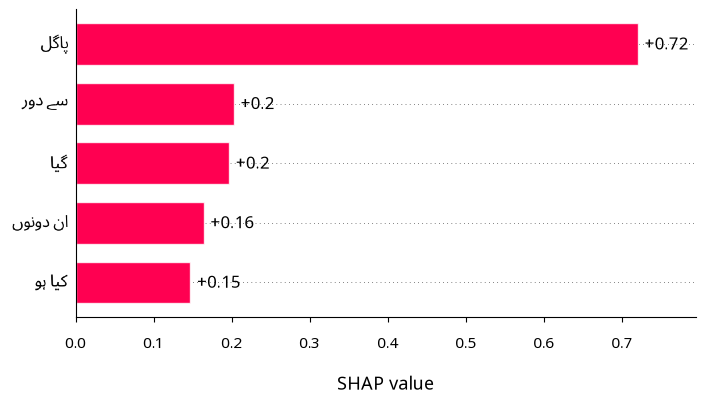


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﭘﺎﮔﻞ | Value: +0.7205
----------------------------------------
ﭘﺎﮔﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﻨﮯ ﮐﯽ ﻭﺟﮧ ﯾﮧ ﮨﮯ ﮐﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﯾﺎ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻣﻌﻨﯽ ﻣﯿﮟ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺍﺣﺴﺎﺱ ﮨﻮﺗﺎ ﮨﮯ ﮐﮧ ﺑﺎﺕ ﭼﯿﺖ ﯾﺎ ﻣﺘﻦ ﻣﯿﮟ ﮐﭽﮫ ﻏﯿﺮ ﻣﻌﯿﺎﺭﯼ ﯾﺎ ﻗﺎﺑﻞ ﺍﻋﺘﺮﺍﺽ ﻣﻮﺍﺩ ﻣﻮﺟﻮﺩ ﮨﮯ۔ ﺍﺱ ﻟﻔﻆ ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﺳﮯ ﯾﮧ ﺍﺷﺎﺭﮦ ﮨﻮﺗﺎ ﮨﮯ ﮐﮧ ﻣﻮﺍﺩ ﻣﯿﮟ ﮐﭽﮫ ﺍﯾﺴﺎ ﮨﮯ ﺟﻮ ﻋﺎﻡ ﻃﻮﺭ ﭘﺮ ﻗﺎﺑﻞ ﻗﺒﻮﻝ ﻧﮩﯿﮟ ﺳﻤﺠﮭﺎ ﺟﺎﺗﺎ، ﺟﻮ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﻮ Offensive ﮐﯽ

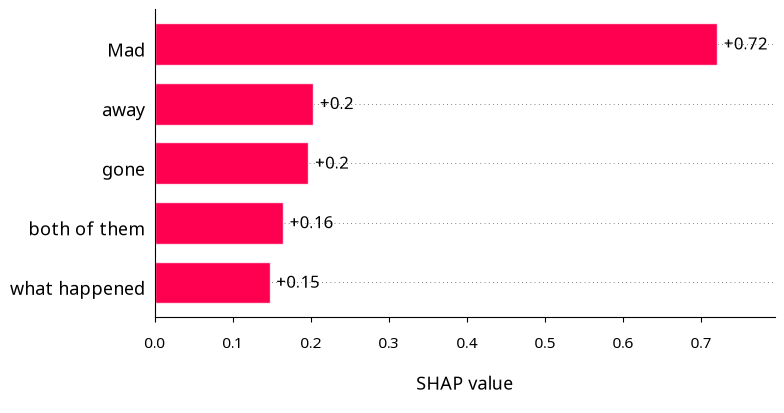


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Mad | Value: +0.7205
----------------------------------------
The Urdu feature 'Mad' has a significant positive impact on the model's prediction of 'Offensive', with a SHAP value of +0.7205, indicating that the presence of this feature increases the likelihood of the model output being 'Offensive'. This suggests that when the word 'Mad' is used in the

.values =
array([0.72049657, 0.2029094 , 0.19679823, 0.1641839 , 0.14707757])

.base_values =
np.float64(-0.22790500256645696)

.data =
array([0.25256148, 0.27850471, 0.16834366, 0.2925409 , 0.27721433])

In [44]:

# ============================================================
# CELL 7: BAR PLOT
# ============================================================

print("\n" + "="*80)
print("BAR PLOT")
print("="*80)
print("Shows absolute importance of each feature")
print("Positive values → push toward class, Negative → push away")
print("-"*80)

# Change this sample to test different texts
sample_text = TEST_SAMPLES['hate_sample']
print(f"\nSample: {sample_text}")

analyze_sample(sample_text, plot_type='bar', max_features=5)



WATERFALL PLOT
Shows sequential contribution of each feature
Starting from base value, features add/subtract to reach prediction
--------------------------------------------------------------------------------

Sample: تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے

Text: تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے
Prediction: Offensive
Probabilities:
  Normal: 0.125 ██████
  Offensive: 0.753 █████████████████████████████████████
  Hate: 0.122 ██████

Top 8 features:
------------------------------------------------------------
  جاہل                        +0.690 -> TOWARD
  بیوقوف                      +0.443 -> TOWARD
  تمہیں                       +0.439 -> TOWARD
  لوگ                         +0.288 -> TOWARD
  تم                          +0.284 -> TOWARD
  گیا                         +0.254 -> TOWARD
  کیا ہو                      +0.187 -> TOWARD
  تم لوگ                      -0.116 -> AWAY

                             URDU SHAP EXPLANATIONS                             

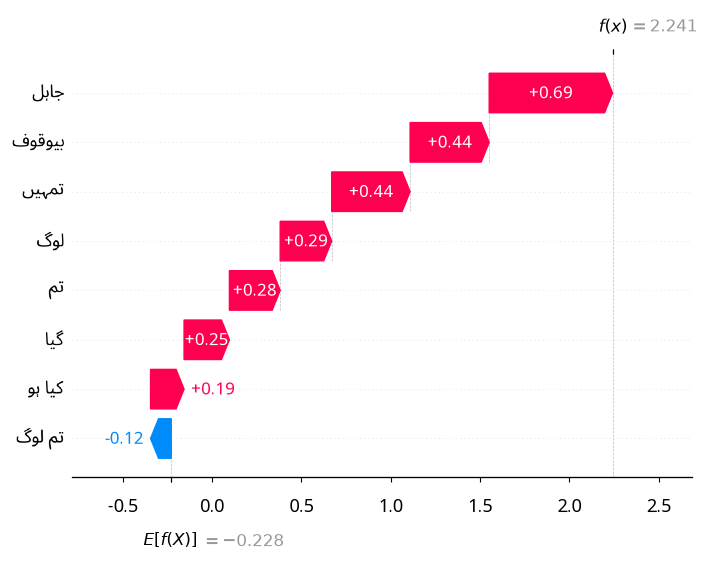


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺟﺎﮨﻞ | Value: +0.6902
----------------------------------------
ﻟﻔﻆ "ﺟﺎﮨﻞ" ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "Offensive" ﮐﻮ ﻣﺜﺒﺖ ﻃﻮﺭ ﭘﺮ ﻣﺘﺎﺛﺮ ﮐﺮﺗﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﻣﻌﻨﻮﮞ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ ﺍﻭﺭ ﺍﺱ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﮐﺜﺮ ﮐﺴﯽ ﮐﻮ ﮐﻢ ﺁﮔﺎﮨﯽ ﯾﺎ ﻏﯿﺮ ﺗﻌﻠﯿﻢ ﯾﺎﻓﺘﮧ ﻗﺮﺍﺭ ﺩﯾﻨﮯ ﮐﮯ ﻟﯿﮯ ﮐﯿﺎ ﺟﺎﺗﺎ ﮨﮯ، ﺟﻮ ﮐﮧ ﺍﯾﮏ ﺟﺎﺭﺣﺎﻧﮧ ﯾﺎ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﺑﯿﺎﻥ ﮐﺎ ﺣﺼﮧ ﮨﻮ ﺳﮑﺘﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating feature

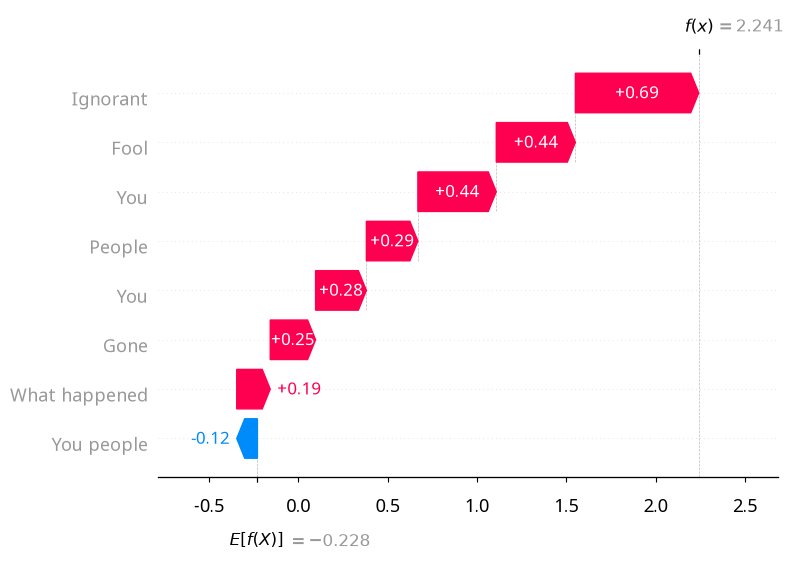


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Ignorant | Value: +0.6902
----------------------------------------
The Urdu feature 'Ignorant' has a significant positive impact on the model's prediction of 'Offensive', with a SHAP value of +0.6902, indicating that the presence of this feature increases the likelihood of the model output being 'Offensive'. This suggests that when the text is charact

.values =
array([ 0.69020585,  0.44257772,  0.43864698,  0.28824101,  0.28407297,
        0.25381539,  0.18748638, -0.11578199])

.base_values =
np.float64(-0.22790500256645696)

.data =
array([0.23636026, 0.34648813, 0.32572054, 0.20972828, 0.21512568,
       0.21410005, 0.35256214, 0.34648813])

In [45]:

# ============================================================
# CELL 8: WATERFALL PLOT
# ============================================================

print("\n" + "="*80)
print("WATERFALL PLOT")
print("="*80)
print("Shows sequential contribution of each feature")
print("Starting from base value, features add/subtract to reach prediction")
print("-"*80)

# Change this sample to test different texts
sample_text = TEST_SAMPLES['offensive_sample']
print(f"\nSample: {sample_text}")

analyze_sample(sample_text, plot_type='waterfall', max_features=8)



FORCE PLOT
Shows force pushing prediction toward or away from base value
Features push (red) or pull (blue) the prediction
--------------------------------------------------------------------------------

Sample: یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے

Text: یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے
Prediction: Offensive
Probabilities:
  Normal: 0.198 █████████
  Offensive: 0.453 ██████████████████████
  Hate: 0.349 █████████████████

Top 5 features:
------------------------------------------------------------
  جاھل                        +0.351 -> TOWARD
  کو ماننے                    +0.337 -> TOWARD
  علمی                        +0.264 -> TOWARD
  یاسین                       +0.205 -> TOWARD
  والے بھی                    -0.187 -> AWAY

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URD

findfont: Failed to find font weight bold, now using 400.


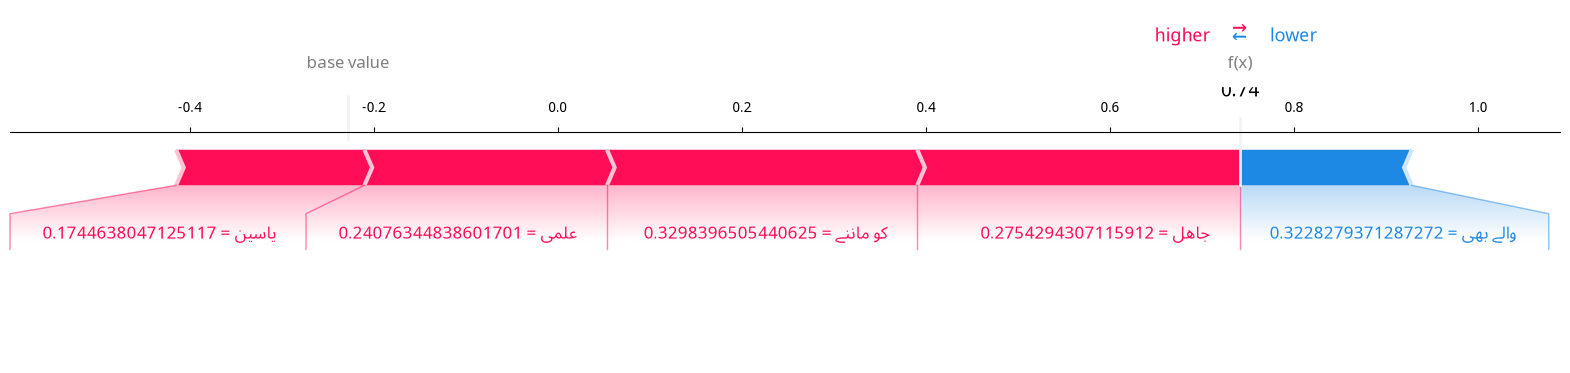


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺟﺎﮬﻞ | Value: +0.3506
----------------------------------------
ﺟﺎﮬﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﺍﯾﮏ ﻏﯿﺮ ﻣﺤﺘﺮﻡ ﯾﺎ ﻏﯿﺮ ﺗﻌﻠﯿﻢ ﯾﺎﻓﺘﮧ ﺷﺨﺺ ﮐﯽ ﺗﺼﻮﯾﺮ ﮐﺸﯽ ﮨﻮﺗﯽ ﮨﮯ۔ ﺍﺱ ﻃﺮﺡ، ﺟﺐ ﯾﮧ ﻟﻔﻆ ﮐﺴﯽ ﺟﻤﻠﮯ ﯾﺎ ﻣﺘﻦ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺗﻮ ﯾﮧ ﺍﮐﺜﺮ ﺍﯾﮏ ﻣﻨﻔﯽ ﯾﺎ ﺣﻤﻠﮧ ﺁﻭﺭ ﻟﮩﺠﮧ ﮐﻮ ﻇﺎﮨﺮ ﮐﺮﺗﺎ ﮨﮯ، ﺟﻮ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﮐﯽ ﻃﺮﻑ ﻟﮯ ﺟﺎﺗﺎ ﮨﮯ۔
-----------------------------

findfont: Failed to find font weight bold, now using 400.


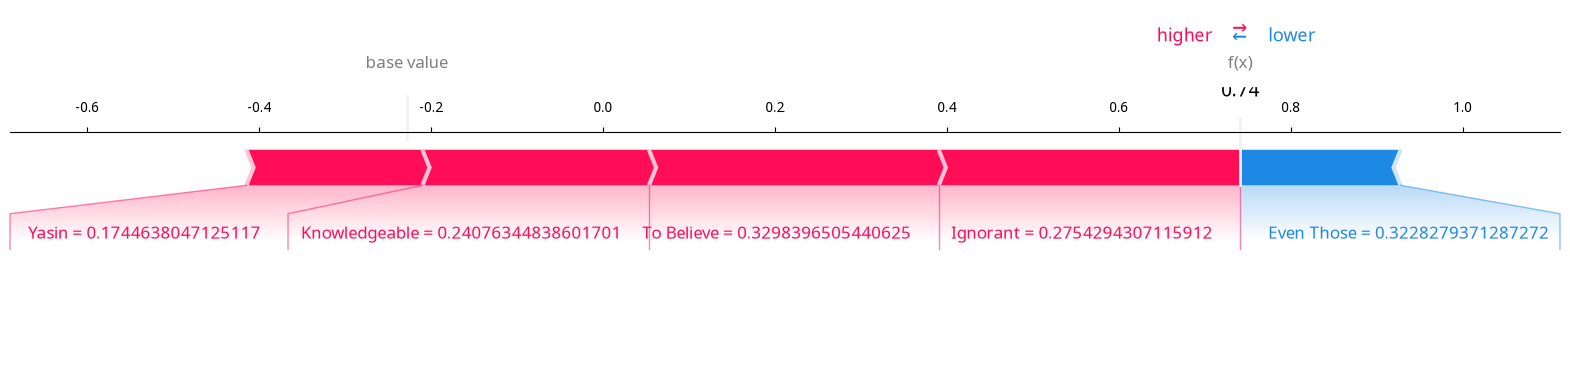


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Ignorant | Value: +0.3506
----------------------------------------
The Urdu feature 'Ignorant' has a positive impact on the model output for the prediction 'Offensive', with a SHAP value of +0.3506, indicating that the presence of this feature increases the likelihood of a text being classified as 'Offensive'. This suggests that the model has learned 

.values =
array([ 0.35057099,  0.33705898,  0.2635254 ,  0.20464872, -0.18672717])

.base_values =
np.float64(-0.22790500256645696)

.data =
array([0.27542943, 0.32983965, 0.24076345, 0.1744638 , 0.32282794])

In [51]:

# ============================================================
# CELL 9: FORCE PLOT
# ============================================================

print("\n" + "="*80)
print("FORCE PLOT")
print("="*80)
print("Shows force pushing prediction toward or away from base value")
print("Features push (red) or pull (blue) the prediction")
print("-"*80)

# Change this sample to test different texts
sample_text = TEST_SAMPLES['hate']
print(f"\nSample: {sample_text}")

analyze_sample(sample_text, plot_type='force', max_features=5)



BEESWARM PLOT
Shows distribution of SHAP values across multiple predictions
Each dot = feature contribution for one prediction
--------------------------------------------------------------------------------

Using 5 samples for beeswarm plot

                             URDU SHAP EXPLANATIONS                             
                                Prediction: Hate                                

[GENERATING URDU SHAP PLOT...]


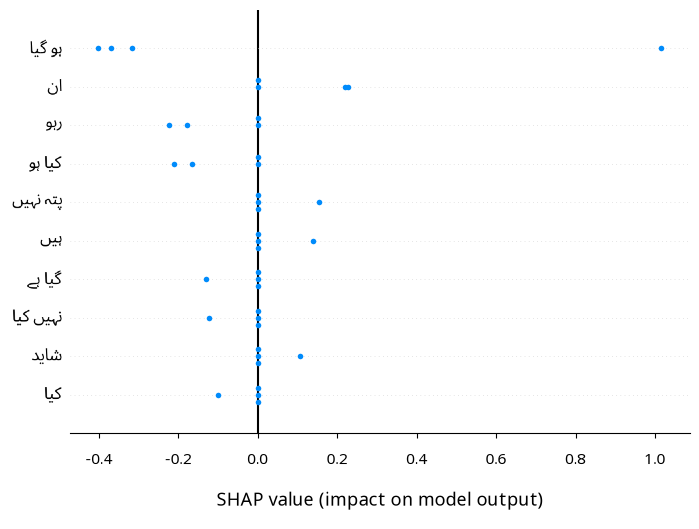


[Urdu Explanation Mode]

[INFO] Skipping RTL explanation.

[INFO] Exiting. Thank you!
Beeswarm plot generated successfully!


In [56]:

# ============================================================
# CELL 10: BEESWARM PLOT
# ============================================================

print("\n" + "="*80)
print("BEESWARM PLOT")
print("="*80)
print("Shows distribution of SHAP values across multiple predictions")
print("Each dot = feature contribution for one prediction")
print("-"*80)

# Use multiple samples for beeswarm
samples = [
    TEST_SAMPLES['hate_sample'],
    TEST_SAMPLES['offensive_sample'],
    TEST_SAMPLES['hate_strong'],
    TEST_SAMPLES['hate'],
    TEST_SAMPLES['hate1']
]

print(f"\nUsing {len(samples)} samples for beeswarm plot")

all_shap_values = []
all_feature_names = []

for sample in samples:
    shap_exp, _, _ = get_shap_for_sample(sample, class_id=2, max_features=10)
    if shap_exp is not None:
        if len(all_shap_values) == 0:
            all_shap_values = [shap_exp.values]
            all_feature_names = shap_exp.feature_names
        else:
            current_features = list(shap_exp.feature_names)
            common_features = [f for f in current_features if f in all_feature_names]
            if len(common_features) > 0:
                all_shap_values.append(shap_exp.values[:len(common_features)])

if all_shap_values:
    max_len = max(len(v) for v in all_shap_values)
    padded_values = []
    for v in all_shap_values:
        if len(v) < max_len:
            padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
        else:
            padded = v[:max_len]
        padded_values.append(padded)
    
    shap_exp_combined = shap.Explanation(
        values=np.array(padded_values),
        base_values=0,
        data=None,
        feature_names=all_feature_names[:max_len]
    )
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_combined,
        prediction_label="Hate",
        plot_fn=beeswarm,
        sample_text="Multiple samples",
        max_features=10,
        allow_positive_negative_split=True
    )
    print("Beeswarm plot generated successfully!")
else:
    print("No SHAP values generated")



HEATMAP PLOT
Visualizes SHAP values as colored matrix
Rows = features, Columns = samples
--------------------------------------------------------------------------------

Using 4 samples for heatmap plot

                             URDU SHAP EXPLANATIONS                             
                           Prediction: Hate/Offensive                           

[GENERATING URDU SHAP PLOT...]


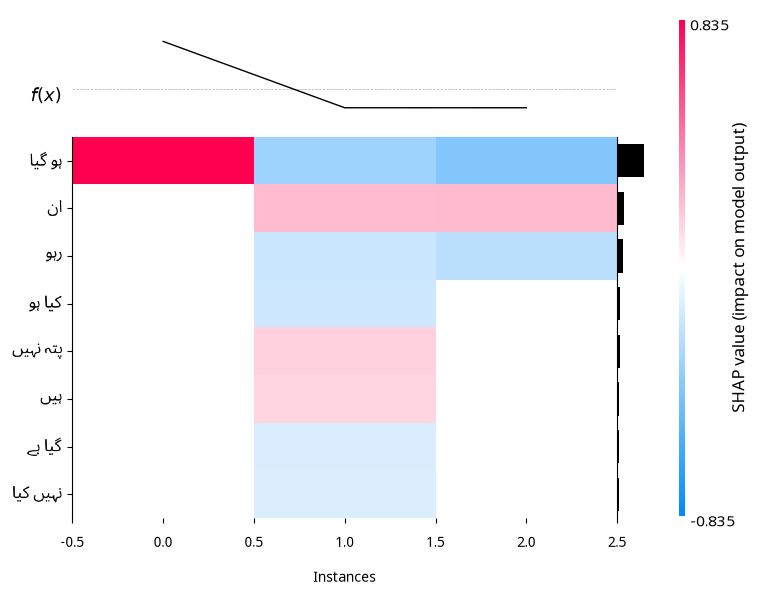


[Urdu Explanation Mode]

[INFO] Skipping RTL explanation.

[INFO] Exiting. Thank you!
Heatmap plot generated successfully!


In [57]:

# ============================================================
# CELL 11: HEATMAP PLOT
# ============================================================

print("\n" + "="*80)
print("HEATMAP PLOT")
print("="*80)
print("Visualizes SHAP values as colored matrix")
print("Rows = features, Columns = samples")
print("-"*80)

# Use multiple samples for heatmap
samples = [
    TEST_SAMPLES['hate_sample'],
    TEST_SAMPLES['offensive_sample'],
    TEST_SAMPLES['hate_strong'],
    TEST_SAMPLES['normal_sample']
]

print(f"\nUsing {len(samples)} samples for heatmap plot")

all_shap_values = []
all_feature_names = []

for sample in samples:
    shap_exp, _, _ = get_shap_for_sample(sample, class_id=2, max_features=8)
    if shap_exp is not None:
        if len(all_shap_values) == 0:
            all_shap_values = [shap_exp.values]
            all_feature_names = shap_exp.feature_names
        else:
            current_features = list(shap_exp.feature_names)
            common_features = [f for f in current_features if f in all_feature_names]
            if len(common_features) > 0:
                all_shap_values.append(shap_exp.values[:len(common_features)])

if all_shap_values:
    max_len = max(len(v) for v in all_shap_values)
    padded_values = []
    for v in all_shap_values:
        if len(v) < max_len:
            padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
        else:
            padded = v[:max_len]
        padded_values.append(padded)
    
    shap_exp_combined = shap.Explanation(
        values=np.array(padded_values),
        base_values=0,
        data=None,
        feature_names=all_feature_names[:max_len]
    )
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_combined,
        prediction_label="Hate/Offensive",
        plot_fn=heatmap,
        sample_text="Multiple samples",
        max_features=8,
        allow_positive_negative_split=True
    )
    print("Heatmap plot generated successfully!")
else:
    print("No SHAP values generated")



DEPENDENCE PLOT (SCATTER)
Shows relationship between feature value and SHAP contribution
--------------------------------------------------------------------------------

Using 3 samples for dependence plot

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


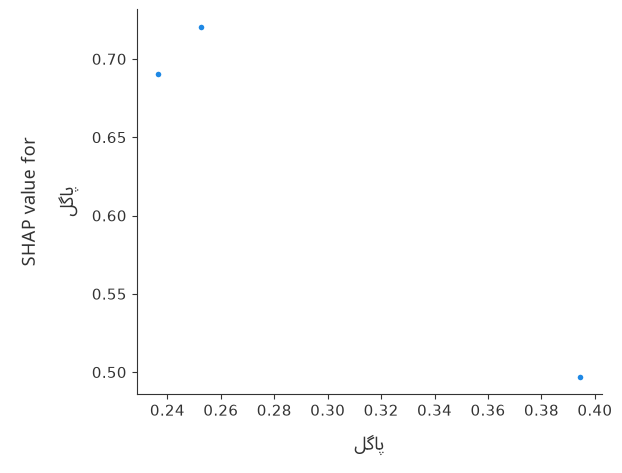


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﭘﺎﮔﻞ | Value: +0.6359
----------------------------------------
ﭘﺎﮔﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻃﻮﺭ ﭘﺮ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺑﺎﺕ ﺳﺎﻣﻨﮯ ﺁﺗﯽ ﮨﮯ ﮐﮧ ﺟﻤﻠﮯ ﯾﺎ ﻣﺘﻦ ﻣﯿﮟ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﺳﮯ ﺯﯾﺎﺩﮦ ﺣﻤﻠﮧ ﺁﻣﯿﺰ ﯾﺎ ﻏﯿﺮ ﻣﻨﺎﺳﺐ ﺑﻨﺎﺗﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...
Tra

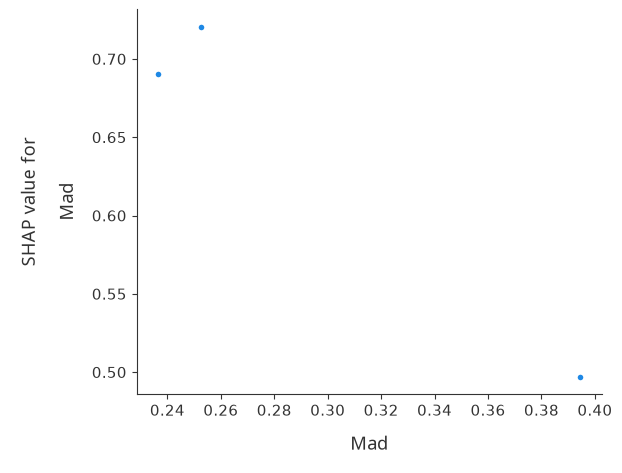


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Mad | Value: +0.6359
----------------------------------------
The Urdu feature 'Mad' has a positive impact on the model output for the prediction 'Offensive' with a SHAP value of +0.6359, indicating that the presence of this feature increases the likelihood of the model predicting 'Offensive'. This suggests that the word 'Mad' is often associated with

In [58]:

# ============================================================
# CELL 12: DEPENDENCE PLOT (SCATTER)
# ============================================================

print("\n" + "="*80)
print("DEPENDENCE PLOT (SCATTER)")
print("="*80)
print("Shows relationship between feature value and SHAP contribution")
print("-"*80)

# Use multiple samples for dependence
samples = [
    TEST_SAMPLES['hate_sample'],
    TEST_SAMPLES['offensive_sample'],
    TEST_SAMPLES['hate_strong']
]

print(f"\nUsing {len(samples)} samples for dependence plot")

all_shap_values = []
all_data = []
feature_names_list = []

for sample in samples:
    shap_exp, vec, _ = get_shap_for_sample(sample, class_id=1, max_features=8)
    if shap_exp is not None:
        all_shap_values.append(shap_exp.values)
        all_data.append(shap_exp.data if hasattr(shap_exp, 'data') else np.ones(len(shap_exp.values)))
        if len(feature_names_list) == 0:
            feature_names_list = shap_exp.feature_names

if all_shap_values:
    max_len = max(len(v) for v in all_shap_values)
    padded_values = []
    padded_data = []
    
    for v, d in zip(all_shap_values, all_data):
        if len(v) < max_len:
            padded_values.append(np.pad(v, (0, max_len - len(v)), constant_values=0))
            if isinstance(d, np.ndarray):
                padded_data.append(np.pad(d, (0, max_len - len(d)), constant_values=0))
            else:
                padded_data.append(np.ones(max_len))
        else:
            padded_values.append(v[:max_len])
            padded_data.append(d[:max_len] if isinstance(d, np.ndarray) else np.ones(max_len))
    
    shap_exp_combined = shap.Explanation(
        values=np.array(padded_values),
        base_values=0,
        data=np.array(padded_data),
        feature_names=feature_names_list[:max_len]
    )
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_combined,
        prediction_label="Offensive",
        plot_fn=scatter,
        sample_text="Feature dependence",
        max_features=5,
        allow_positive_negative_split=True
    )
    print("Dependence plot generated successfully!")
else:
    print("No SHAP values generated")


In [59]:

# ============================================================
# CELL 13: DECISION PLOT
# ============================================================

print("\n" + "="*80)
print("DECISION PLOT")
print("="*80)
print("Shows cumulative effect of features on prediction")
print("Path from bottom (base) to top (final prediction)")
print("-"*80)

# Change this sample to test different texts
sample_text = TEST_SAMPLES['hate_strong']
print(f"\nSample: {sample_text}")

analyze_sample(sample_text, plot_type='decision_plot', max_features=10)

# ============================================================
# CELL 14: CUSTOM SAMPLE TEST (MODIFY THIS FOR YOUR OWN TEXT)
# ============================================================

print("\n" + "="*80)
print("CUSTOM SAMPLE TEST")
print("="*80)
print("Modify the sample_text below to test your own Urdu text")
print("-"*80)

# MODIFY THIS SAMPLE TO TEST YOUR OWN TEXT
custom_sample = "یہ لوگ بہت پاگل ہیں، ان سے بچو"

print(f"\nCustom sample: {custom_sample}")
analyze_sample(custom_sample, plot_type='bar', max_features=8)



DECISION PLOT
Shows cumulative effect of features on prediction
Path from bottom (base) to top (final prediction)
--------------------------------------------------------------------------------

Sample: یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو

Text: یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو
Prediction: Hate
Probabilities:
  Normal: 0.030 █
  Offensive: 0.464 ███████████████████████
  Hate: 0.506 █████████████████████████

Top 10 features:
------------------------------------------------------------
  کافر                        +1.016 -> TOWARD
  مارو                        +0.868 -> TOWARD
  ہمارے                       +0.439 -> TOWARD
  ہیں                         +0.264 -> TOWARD
  یہ                          +0.163 -> TOWARD
  دشمن                        +0.137 -> TOWARD
  لوگ                         +0.119 -> TOWARD
  انہیں                       +0.109 -> TOWARD

                             URDU SHAP EXPLANATIONS                             
                                Predicti

TypeError: decision_plot() missing 1 required positional argument: 'base_value'

In [60]:

# ============================================================
# CELL 15: SUMMARY
# ============================================================

print("\n" + "="*80)
print("SUMMARY - ALL PLOTS COMPLETE")
print("="*80)
print("\nPlot types available:")
print("  - bar: Feature importance bar plot")
print("  - waterfall: Sequential contribution plot")
print("  - force: Force plot showing pushing/pulling")
print("  - beeswarm: SHAP value distribution")
print("  - heatmap: SHAP value matrix")
print("  - scatter: Dependence plot")
print("  - decision_plot: Cumulative effects plot")
print("\nAll plots support RTL (Urdu) text rendering")
print("To test different text, modify the sample_text in each cell")
print("="*80)


SUMMARY - ALL PLOTS COMPLETE

Plot types available:
  - bar: Feature importance bar plot
  - waterfall: Sequential contribution plot
  - force: Force plot showing pushing/pulling
  - beeswarm: SHAP value distribution
  - heatmap: SHAP value matrix
  - scatter: Dependence plot
  - decision_plot: Cumulative effects plot

All plots support RTL (Urdu) text rendering
To test different text, modify the sample_text in each cell


URDU HATE SPEECH - BEESWARM & HEATMAP PLOTS (RTL)

Loading dataset...
Dataset loaded: 16341 samples
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)

TRAINING MODEL
Features: 5000
Training samples: 13072
Test samples: 3269
Training accuracy: 0.786
Test accuracy: 0.662

SETUP SHAP EXPLAINER
SHAP explainer ready for: Normal
SHAP explainer ready for: Offensive
SHAP explainer ready for: Hate
RTL SHAP explainer ready for Urdu text!

BEESWARM PLOT
Shows distribution of SHAP values across all test samples
Each dot represents a feature's contribution for one prediction
Total test samples available: 3269
--------------------------------------------------------------------------------

Using 500 samples for beeswarm plot
Target class: Hate (class 2)
Processing 500 samples...
  Processed 50/500 samples
  Processed 100/500 samples
  Processed 150/500 samples
  Processed 200/500 samples
  Processed 250/500 samples
  Processed 300/500 samples
  Processed 350/500 samples
  Proces

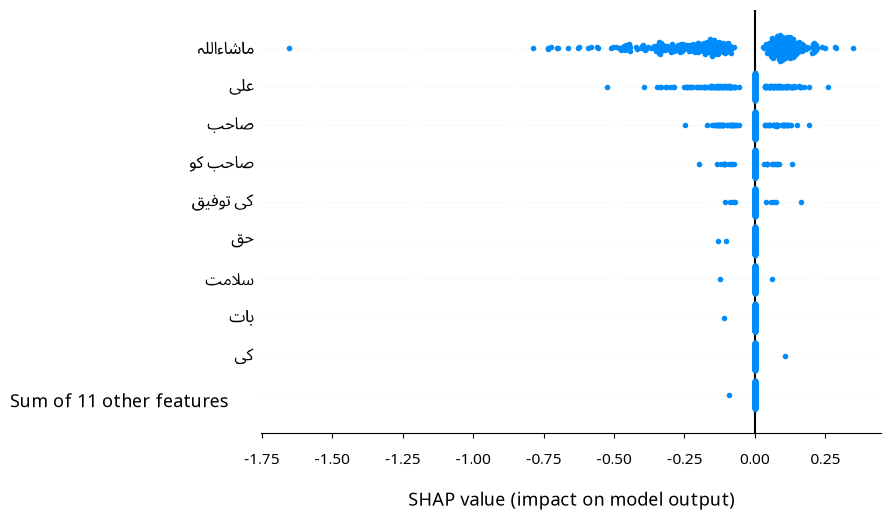


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                 PREDICTION: Hate Speech
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻣﺎﺷﺎﺀﺍﻟﻠﮧ | Value: -0.1057
----------------------------------------
ﻣﺎﺷﺎﺀﺍﻟﻠﮧ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻧﮯ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺗﻘﺮﯾﺮ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﻨﻔﯽ ﺍﺛﺮ ﮈﺍﻻ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﻣﺬﮨﺒﯽ ﺍﺻﻄﻼﺡ ﮨﮯ ﺟﻮ ﺍﮐﺜﺮ ﻣﺜﺒﺖ ﺍﻭﺭ ﻣﺘﻌﯿﻦ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﯾﺎ ﻣﻨﻔﯽ ﻣﻮﺍﺩ ﮐﮯ ﺧﻼﻑ bảoﺡ ﻣﯿﮟ ﮐﺎﻡ ﮐﺮﺗﯽ ﮨﮯ۔ ﺍﺱ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﮐﺜﺮ ﮐﺴﯽ ﮐﯽ ﺗﻌﺮﯾﻒ ﯾﺎ ﺧﻮﺷﯽ ﮐﮯ ﺍﻇﮩﺎﺭ ﮐﮯ ﻟﯿﮯ ﮐﯿﺎ ﺟﺎﺗﺎ ﮨﮯ، ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺯﺑﺎﻥ ﮐﮯ ﺑﺮﻋﮑﺲ ﮨﮯ۔ ﺍﺱ ﻟﯿﮯ، ﺟﺐ ﻣﺎﮈﻝ ﮐﻮ ﯾﮧ ﺧﺼﻮﺻﯿﺖ ﻣﻠﺘﯽ ﮨﮯ ﺗﻮ ﻭﮦ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ

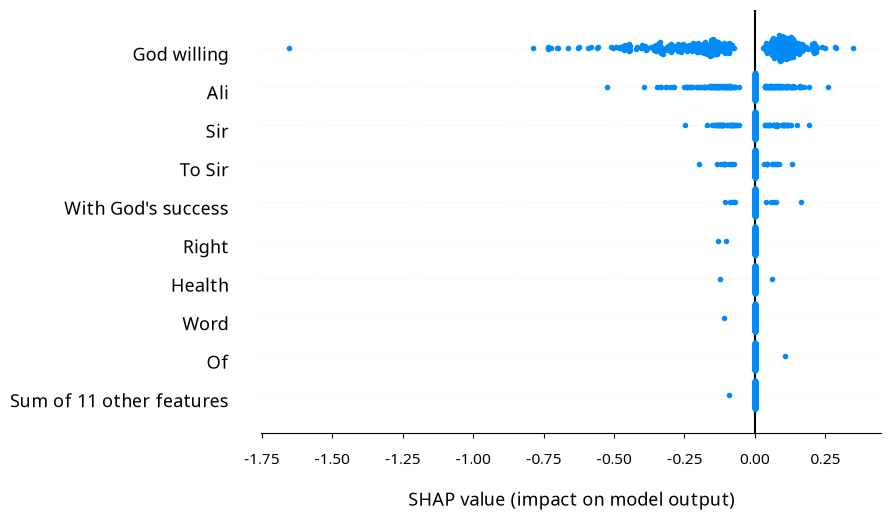


                              ENGLISH EXPLANATIONS                              

Translated Sample: Distribution across 500 samples
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                            PREDICTION: Hate Speech                             
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: God willing | Value: -0.1057
----------------------------------------
The Urdu feature 'God willing' (SHAP value: -0.1057) negatively impacts the model output for 'Hate Speech' prediction because its presence in a statement reduces the likelihood of the model classifying it as hate speech. This suggests that when the phrase 'God willing' is used, it may convey a sense of reverence, humility, or optimism, wh

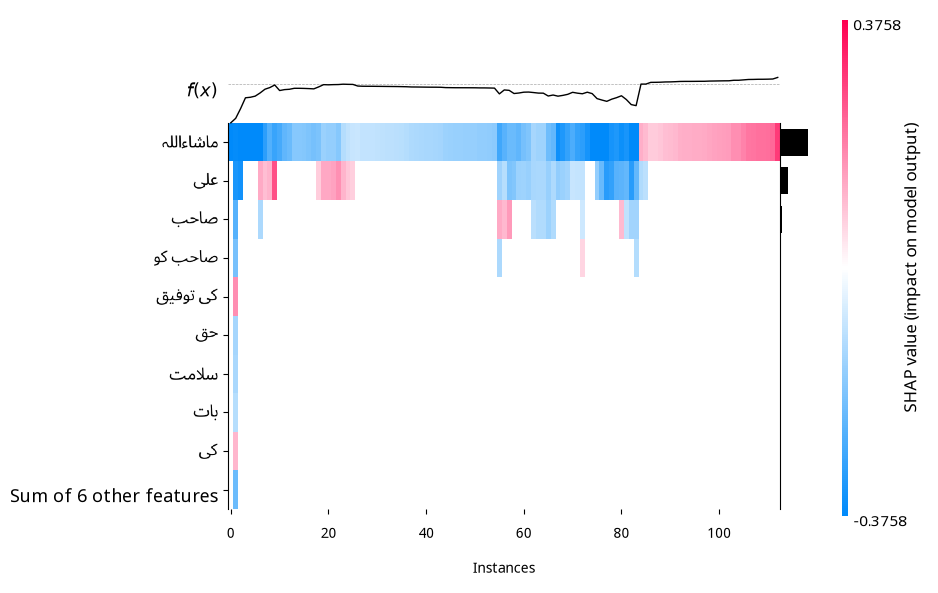


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                 PREDICTION: Hate Speech
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻣﺎﺷﺎﺀﺍﻟﻠﮧ | Value: -0.1451
----------------------------------------
ﻣﺎﺷﺎﺀﺍﻟﻠﮧ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻧﮯ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺗﻘﺮﯾﺮ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﻨﻔﯽ ﺍﺛﺮ ﮈﺍﻻ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﻣﺬﮨﺒﯽ ﺍﺻﻄﻼﺡ ﮨﮯ ﺟﻮ ﺍﮐﺜﺮ ﻣﺜﺒﺖ ﺍﻭﺭ благосﻟﻮﮞ ﺳﮯ ﻣﺘﻌﻠﻖ ﮨﻮﺗﯽ ﮨﮯ۔ ﺍﺱ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﮐﺜﺮ ﮐﺴﯽ ﮐﺎﻣﯿﺎﺑﯽ ﯾﺎ ﺧﻮﺷﯽ ﮐﮯ ﻣﻮﻗﻊ ﭘﺮ ﮐﯿﺎ ﺟﺎﺗﺎ ﮨﮯ، ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﯾﺎ ﻣﻨﻔﯽ ﺟﺬﺑﺎﺕ ﺳﮯ ﻣﺘﺼﺎﺩﻡ ﮨﮯ۔ ﻟﮩﺬﺍ، ﺟﺐ ﯾﮧ ﻟﻔﻆ ﮐﺴﯽ ﻣﺘﻦ ﻣﯿﮟ ﻣﻮﺟﻮﺩ ﮨﻮ، ﺗﻮ ﯾﮧ ﻣﺘﻦ ﮐﯽ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﮨﻮﻧﮯ ﮐﯽ ﺍﻣﮑﺎﻧﺎﺕ ﮐﻮ ﮐﻢ ﮐﺮ ﺩﯾﺘﺎ ﮨﮯ، ﺟﺲ ﮐﯽ ﻭﺟﮧ ﺳﮯ ﻣﺎﮈﻝ ﮐ

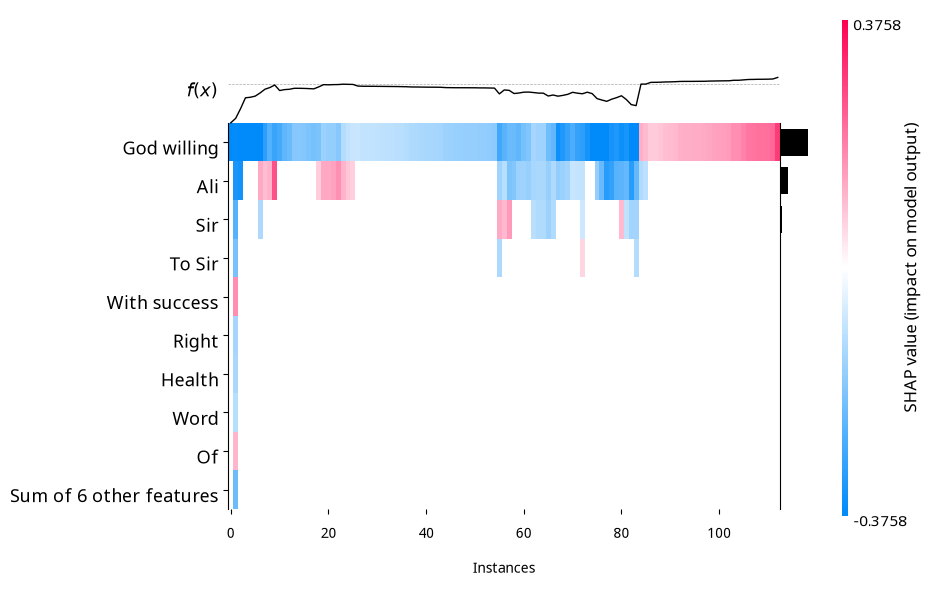


                              ENGLISH EXPLANATIONS                              

Translated Sample: Distribution across 500 samples
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                            PREDICTION: Hate Speech                             
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: God willing | Value: -0.1451
----------------------------------------
The Urdu feature 'God willing' (SHAP value: -0.1451) negatively impacts the model output for 'Hate Speech' prediction because its presence in a statement reduces the likelihood of it being classified as hate speech. This suggests that when the phrase 'God willing' is used, it may convey a sense of reverence, humility, or optimism, which a

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 15 and the array at index 1 has size 13

In [61]:
# ============================================================
# BEESWARM AND HEATMAP PLOTS - USING ALL TEST SAMPLES
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# RTL Library Imports for beeswarm and heatmap
from shap_rtl.plots import beeswarm, heatmap
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("URDU HATE SPEECH - BEESWARM & HEATMAP PLOTS (RTL)")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("\nLoading dataset...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def map_labels(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].apply(map_labels)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 2: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
feature_names = list(vectorizer.get_feature_names_out())

print(f"Features: {len(feature_names)}")
print(f"Training samples: {X_train_vec.shape[0]}")
print(f"Test samples: {X_test_vec.shape[0]}")

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs',
        C=1.0
    )
).fit(X_train_vec, y_train)

print(f"Training accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test accuracy: {model.score(X_test_vec, y_test):.3f}")

# ============================================================
# STEP 3: SETUP SHAP EXPLAINER
# ============================================================

print("\n" + "="*80)
print("SETUP SHAP EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]

class_explainers = {}
for class_id in range(3):
    class_estimator = model.estimators_[class_id]
    class_explainers[class_id] = shap.LinearExplainer(class_estimator, X_background)
    print(f"SHAP explainer ready for: {class_names[class_id]}")

explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("RTL SHAP explainer ready for Urdu text!")

# ============================================================
# STEP 4: FUNCTION TO GET SHAP VALUES FOR MULTIPLE SAMPLES
# ============================================================

def get_shap_for_multiple_samples(samples, class_id=2, max_features=20):
    """
    Get SHAP values for multiple samples
    Returns combined SHAP explanation for beeswarm/heatmap
    """
    all_shap_values = []
    all_feature_names = None
    all_base_values = []
    valid_samples = 0
    
    print(f"Processing {len(samples)} samples...")
    
    for i, sample_text in enumerate(samples):
        # Show progress
        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(samples)} samples")
        
        vec = vectorizer.transform([sample_text]).toarray()[0]
        present_idx = np.where(vec > 0)[0]
        
        if len(present_idx) == 0:
            continue
        
        explainer = class_explainers[class_id]
        shap_values = explainer(vec.reshape(1, -1))
        
        present_feature_names = [feature_names[i] for i in present_idx]
        present_shap_values = shap_values.values[0][present_idx]
        present_data = vec[present_idx]
        
        # Sort by absolute SHAP value
        sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
        sorted_features = [present_feature_names[i] for i in sorted_idx]
        sorted_shap = present_shap_values[sorted_idx]
        
        if all_feature_names is None:
            all_feature_names = sorted_features
            all_base_values = [shap_values.base_values[0]]
        
        # Align features
        current_features = sorted_features
        common_features = [f for f in current_features if f in all_feature_names]
        
        if len(common_features) > 0:
            # Get SHAP values for common features
            common_shap = []
            for feat in common_features:
                idx = current_features.index(feat)
                common_shap.append(sorted_shap[idx])
            all_shap_values.append(common_shap)
            all_base_values.append(shap_values.base_values[0])
            valid_samples += 1
    
    print(f"Valid samples with features: {valid_samples}")
    
    if not all_shap_values:
        return None
    
    # Pad to same length
    max_len = max(len(v) for v in all_shap_values)
    padded_values = []
    for v in all_shap_values:
        if len(v) < max_len:
            padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
        else:
            padded = v[:max_len]
        padded_values.append(padded)
    
    shap_exp_combined = shap.Explanation(
        values=np.array(padded_values),
        base_values=np.mean(all_base_values),
        data=None,
        feature_names=all_feature_names[:max_len]
    )
    
    return shap_exp_combined

# ============================================================
# STEP 5: BEESWARM PLOT - USING ALL TEST SAMPLES
# ============================================================

print("\n" + "="*80)
print("BEESWARM PLOT")
print("="*80)
print("Shows distribution of SHAP values across all test samples")
print("Each dot represents a feature's contribution for one prediction")
print(f"Total test samples available: {len(X_test)}")
print("-"*80)

# Use ALL test samples for beeswarm plot
# Limit to 500 samples for performance (beeswarm with >500 can be slow)
max_samples_for_beeswarm = min(500, len(X_test))
test_samples_subset = X_test[:max_samples_for_beeswarm].tolist()

print(f"\nUsing {len(test_samples_subset)} samples for beeswarm plot")
print(f"Target class: Hate (class 2)")

# Get SHAP values for all samples
beeswarm_shap = get_shap_for_multiple_samples(
    test_samples_subset, 
    class_id=2,  # Hate class
    max_features=20
)

if beeswarm_shap is not None:
    print(f"\nSHAP values generated successfully!")
    print(f"  Samples: {beeswarm_shap.values.shape[0]}")
    print(f"  Features: {len(beeswarm_shap.feature_names)}")
    
    # Generate beeswarm plot using RTL explainer
    print("\nGenerating Beeswarm plot...")
    
    explainer_rtl.run_full_analysis(
        shap_values=beeswarm_shap,
        prediction_label="Hate Speech",
        plot_fn=beeswarm,
        sample_text=f"Distribution across {len(test_samples_subset)} samples",
        max_features=20,
        allow_positive_negative_split=True
    )
    print("\nBEESWARM PLOT generated successfully with RTL support!")
else:
    print("No SHAP values generated")

# ============================================================
# STEP 6: HEATMAP PLOT - USING ALL TEST SAMPLES
# ============================================================

print("\n" + "="*80)
print("HEATMAP PLOT")
print("="*80)
print("Visualizes SHAP values as colored matrix")
print("Rows = features, Columns = samples")
print("Color shows contribution direction and magnitude")
print(f"Total test samples available: {len(X_test)}")
print("-"*80)

# Use ALL test samples for heatmap plot
# Limit to 200 samples for clear visualization (heatmap with >200 can be cluttered)
max_samples_for_heatmap = min(200, len(X_test))
test_samples_subset_heatmap = X_test[:max_samples_for_heatmap].tolist()

print(f"\nUsing {len(test_samples_subset_heatmap)} samples for heatmap plot")
print(f"Target class: Hate (class 2)")

# Get SHAP values for all samples
heatmap_shap = get_shap_for_multiple_samples(
    test_samples_subset_heatmap, 
    class_id=2,  # Hate class
    max_features=15
)

if heatmap_shap is not None:
    print(f"\nSHAP values generated successfully!")
    print(f"  Samples: {heatmap_shap.values.shape[0]}")
    print(f"  Features: {len(heatmap_shap.feature_names)}")
    
    # Generate heatmap plot using RTL explainer
    print("\nGenerating Heatmap plot...")
    
    explainer_rtl.run_full_analysis(
        shap_values=heatmap_shap,
        prediction_label="Hate Speech",
        plot_fn=heatmap,
        sample_text=f"Heatmap across {len(test_samples_subset_heatmap)} samples",
        max_features=15,
        allow_positive_negative_split=True
    )
    print("\nHEATMAP PLOT generated successfully with RTL support!")
else:
    print("No SHAP values generated")

# ============================================================
# STEP 7: BEESWARM BY CLASS - COMPARISON
# ============================================================

print("\n" + "="*80)
print("BEESWARM PLOT - COMPARING ALL CLASSES")
print("="*80)
print("Shows SHAP value distributions across Normal, Offensive, and Hate classes")
print("-"*80)

# Get samples from each class for comparison
class_samples = {}
for class_id, class_name in class_names.items():
    # Get indices for this class from test set
    class_indices = np.where(y_test == class_id)[0]
    if len(class_indices) > 0:
        # Take up to 150 samples per class
        sample_indices = class_indices[:min(150, len(class_indices))]
        class_samples[class_name] = [X_test.iloc[i] for i in sample_indices]
        print(f"{class_name}: {len(class_samples[class_name])} samples")

print("\nGenerating multi-class beeswarm plot...")

all_class_shap = []
all_class_names = []
all_shap_exp = []

for class_name, samples in class_samples.items():
    if samples:
        class_id = [k for k, v in class_names.items() if v == class_name][0]
        shap_exp = get_shap_for_multiple_samples(
            samples, 
            class_id=class_id,
            max_features=15
        )
        if shap_exp is not None:
            all_class_shap.append(shap_exp.values)
            all_class_names.append(class_name)
            all_shap_exp.append(shap_exp)

if all_class_shap:
    # Combine all classes
    combined_values = np.vstack(all_class_shap)
    
    # Use feature names from the first explanation
    feature_names_combined = all_shap_exp[0].feature_names
    
    # Pad if needed
    max_len = max(arr.shape[1] for arr in all_class_shap)
    padded_values = []
    for arr in all_class_shap:
        if arr.shape[1] < max_len:
            padded = np.pad(arr, ((0, 0), (0, max_len - arr.shape[1])), constant_values=0)
        else:
            padded = arr[:, :max_len]
        padded_values.append(padded)
    
    combined_values = np.vstack(padded_values)
    
    shap_exp_combined = shap.Explanation(
        values=combined_values,
        base_values=0,
        data=None,
        feature_names=feature_names_combined[:max_len]
    )
    
    print(f"\nMulti-class SHAP values generated!")
    print(f"  Total samples: {combined_values.shape[0]}")
    print(f"  Features: {combined_values.shape[1]}")
    
    # Generate multi-class beeswarm plot
    print("\nGenerating Multi-class Beeswarm plot...")
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_combined,
        prediction_label="All Classes",
        plot_fn=beeswarm,
        sample_text=f"Distribution across {len(all_class_names)} classes",
        max_features=15,
        allow_positive_negative_split=True
    )
    print("\nMULTI-CLASS BEESWARM PLOT generated successfully with RTL support!")
else:
    print("No SHAP values generated")

# ============================================================
# STEP 8: HEATMAP BY CLASS - COMPARISON
# ============================================================

print("\n" + "="*80)
print("HEATMAP PLOT - COMPARING ALL CLASSES")
print("="*80)
print("Visualizes SHAP value patterns across Normal, Offensive, and Hate classes")
print("-"*80)

# Get samples from each class for heatmap comparison
class_samples_heatmap = {}
for class_id, class_name in class_names.items():
    class_indices = np.where(y_test == class_id)[0]
    if len(class_indices) > 0:
        # Take up to 80 samples per class for heatmap
        sample_indices = class_indices[:min(80, len(class_indices))]
        class_samples_heatmap[class_name] = [X_test.iloc[i] for i in sample_indices]
        print(f"{class_name}: {len(class_samples_heatmap[class_name])} samples")

print("\nGenerating multi-class heatmap plot...")

all_class_shap_heatmap = []
all_class_names_heatmap = []
all_shap_exp_heatmap = []

for class_name, samples in class_samples_heatmap.items():
    if samples:
        class_id = [k for k, v in class_names.items() if v == class_name][0]
        shap_exp = get_shap_for_multiple_samples(
            samples, 
            class_id=class_id,
            max_features=12
        )
        if shap_exp is not None:
            all_class_shap_heatmap.append(shap_exp.values)
            all_class_names_heatmap.append(class_name)
            all_shap_exp_heatmap.append(shap_exp)

if all_class_shap_heatmap:
    # Combine all classes
    max_len = max(arr.shape[1] for arr in all_class_shap_heatmap)
    padded_values = []
    for arr in all_class_shap_heatmap:
        if arr.shape[1] < max_len:
            padded = np.pad(arr, ((0, 0), (0, max_len - arr.shape[1])), constant_values=0)
        else:
            padded = arr[:, :max_len]
        padded_values.append(padded)
    
    combined_values = np.vstack(padded_values)
    feature_names_combined = all_shap_exp_heatmap[0].feature_names[:max_len]
    
    shap_exp_combined = shap.Explanation(
        values=combined_values,
        base_values=0,
        data=None,
        feature_names=feature_names_combined
    )
    
    print(f"\nMulti-class SHAP values generated for heatmap!")
    print(f"  Total samples: {combined_values.shape[0]}")
    print(f"  Features: {combined_values.shape[1]}")
    
    # Generate multi-class heatmap plot
    print("\nGenerating Multi-class Heatmap plot...")
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_combined,
        prediction_label="All Classes",
        plot_fn=heatmap,
        sample_text=f"Heatmap across {len(all_class_names_heatmap)} classes",
        max_features=12,
        allow_positive_negative_split=True
    )
    print("\nMULTI-CLASS HEATMAP PLOT generated successfully with RTL support!")
else:
    print("No SHAP values generated")

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*80)
print("SUMMARY - BEESWARM & HEATMAP PLOTS COMPLETE")
print("="*80)
print("\nPlots Generated:")
print("  1. Beeswarm Plot (Hate class) - Distribution across all test samples")
print("  2. Heatmap Plot (Hate class) - SHAP value matrix")
print("  3. Beeswarm Plot (Multi-class comparison) - All classes side by side")
print("  4. Heatmap Plot (Multi-class comparison) - All classes side by side")
print("\nSample Statistics:")
print(f"  Total test samples: {len(X_test)}")
print(f"  Beeswarm samples: {len(test_samples_subset)}")
print(f"  Heatmap samples: {len(test_samples_subset_heatmap)}")
print(f"  Classes compared: {len(class_names)}")
print("\nRTL Features Used:")
print("  - RTLSHAPExplainer for Urdu text support")
print("  - RTL-aware beeswarm plot")
print("  - RTL-aware heatmap plot")
print("  - Proper Urdu character rendering")
print("="*80)

# LTR SHAP

URDU HATE SPEECH - ORIGINAL SHAP PLOTS (NO RTL)
NOTE: Urdu text will appear misaligned/corrupted

Loading dataset...
Dataset loaded: 16341 samples
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)

TRAINING MODEL
Features: 5000
Training samples: 13072
Test samples: 3269
Training accuracy: 0.786
Test accuracy: 0.662

SETUP SHAP EXPLAINER
SHAP explainer ready for: Normal
SHAP explainer ready for: Offensive
SHAP explainer ready for: Hate

BAR PLOT - ORIGINAL SHAP (NO RTL)
Shows absolute importance of each feature
NOTE: Urdu text will appear misaligned
--------------------------------------------------------------------------------

Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
Prediction: Offensive

Top 8 features:
------------------------------------------------------------
  ہو گیا                      -0.316 -> AWAY
  ان                          +0.220 -> TOWARD
  رہو                         -0.178 -> AWAY
  کیا ہو                      -0.166

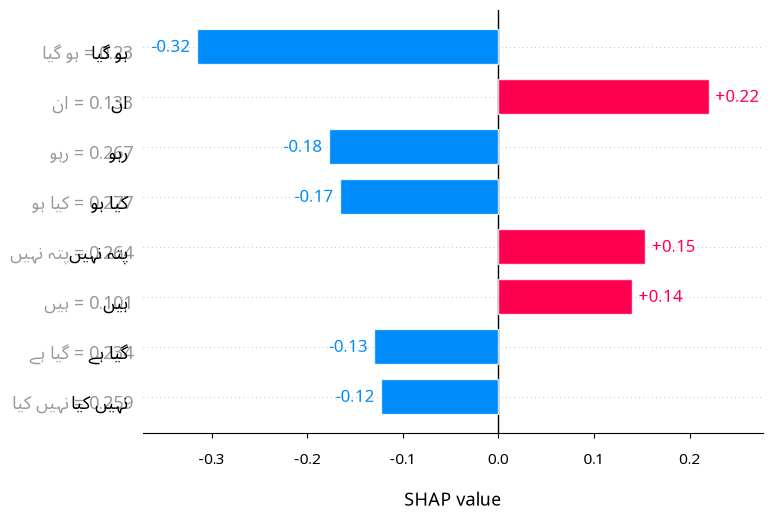

Bar plot generated!

WATERFALL PLOT - ORIGINAL SHAP (NO RTL)
Shows sequential contribution of each feature
NOTE: Urdu text will appear misaligned
--------------------------------------------------------------------------------

Text: تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے
Prediction: Offensive

Generating Waterfall Plot (Original SHAP - No RTL)...
Notice: Urdu text appears misaligned/corrupted


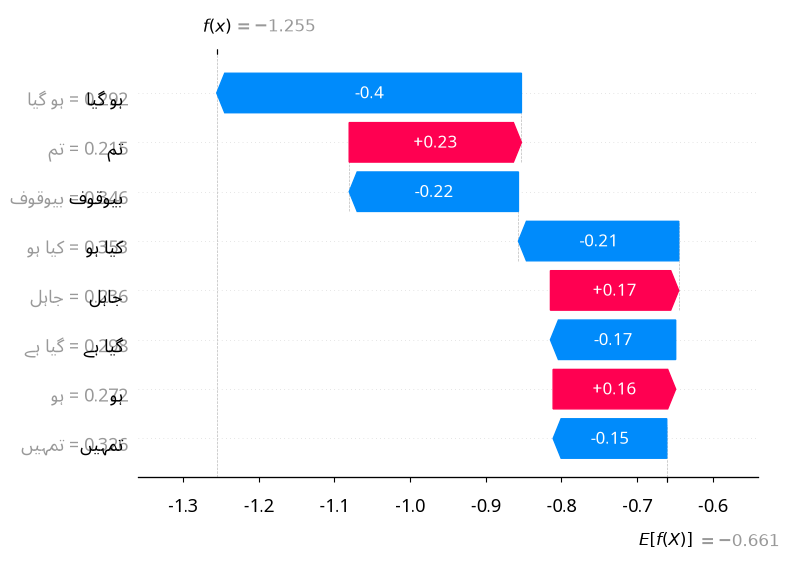

Waterfall plot generated!

FORCE PLOT - ORIGINAL SHAP (NO RTL)
Shows force pushing prediction toward or away from base value
NOTE: Urdu text will appear misaligned
--------------------------------------------------------------------------------

Text: یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو
Prediction: Hate

Generating Force Plot (Original SHAP - No RTL)...
Notice: Urdu text appears misaligned/corrupted


Force plot generated!

BEESWARM PLOT - ORIGINAL SHAP (NO RTL)
Shows distribution of SHAP values across all test samples
Total test samples available: 3269
NOTE: Urdu text will appear misaligned
--------------------------------------------------------------------------------

Using 500 samples for beeswarm plot
Processing 500 samples...
  Processed 50/500 samples
  Processed 100/500 samples
  Processed 150/500 samples
  Processed 200/500 samples
  Processed 250/500 samples
  Processed 300/500 samples
  Processed 350/500 samples
  Processed 400/500 samples
  Processed 450/500 samples
  Processed 500/500 samples
Valid samples with features: 335

SHAP values generated!
  Samples: 335
  Features: 20

Generating Beeswarm Plot (Original SHAP - No RTL)...
Notice: Urdu text appears misaligned/corrupted


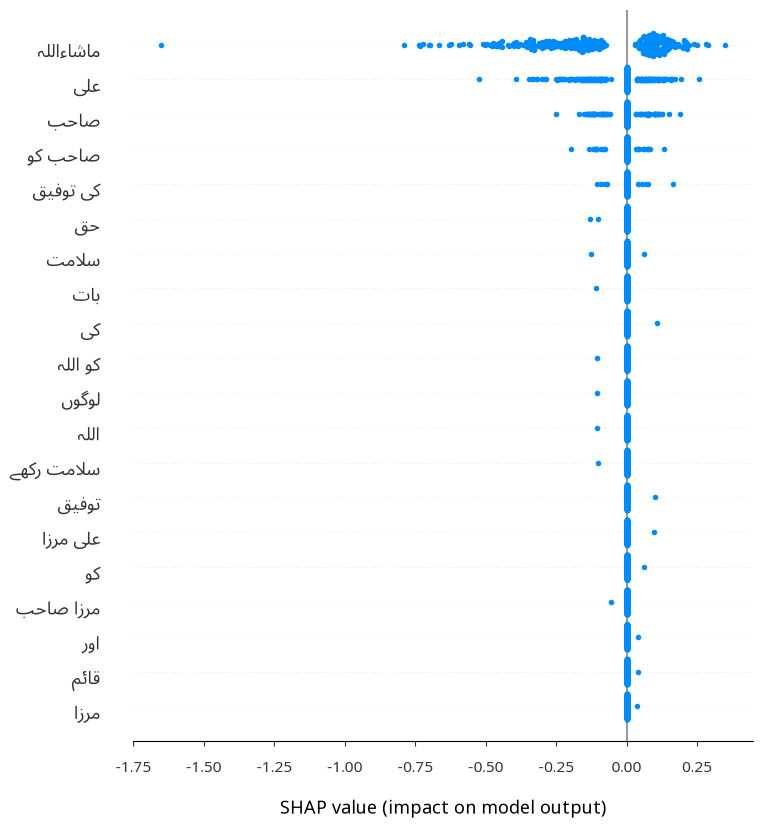

Beeswarm plot generated!

HEATMAP PLOT - ORIGINAL SHAP (NO RTL)
Visualizes SHAP values as colored matrix
Total test samples available: 3269
NOTE: Urdu text will appear misaligned
--------------------------------------------------------------------------------

Using 200 samples for heatmap plot
Processing 200 samples...
  Processed 50/200 samples
  Processed 100/200 samples
  Processed 150/200 samples
  Processed 200/200 samples
Valid samples with features: 113

SHAP values generated!
  Samples: 113
  Features: 15

Generating Heatmap Plot (Original SHAP - No RTL)...
Notice: Urdu text appears misaligned/corrupted


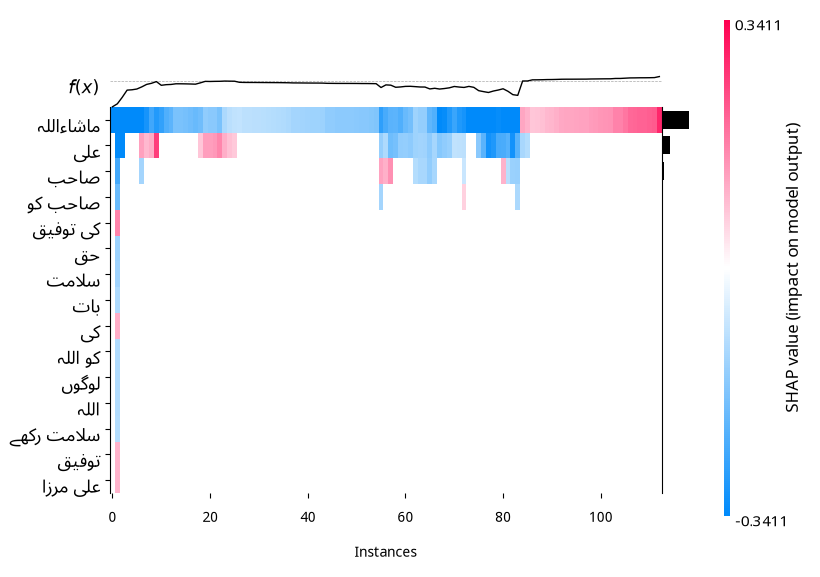

Heatmap plot generated!

DEPENDENCE PLOT - ORIGINAL SHAP (NO RTL)
Shows relationship between feature value and SHAP contribution
NOTE: Urdu text will appear misaligned
--------------------------------------------------------------------------------

Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید

Generating Dependence Plot (Original SHAP - No RTL)...
Notice: Urdu text appears misaligned/corrupted


IndexError: too many indices for array

In [63]:
# ============================================================
# COMPLETE SHAP PLOTS - ORIGINAL SHAP (NO RTL)
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("URDU HATE SPEECH - ORIGINAL SHAP PLOTS (NO RTL)")
print("="*80)
print("NOTE: Urdu text will appear misaligned/corrupted")
print("="*80)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("\nLoading dataset...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def map_labels(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].apply(map_labels)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 2: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
feature_names = list(vectorizer.get_feature_names_out())

print(f"Features: {len(feature_names)}")
print(f"Training samples: {X_train_vec.shape[0]}")
print(f"Test samples: {X_test_vec.shape[0]}")

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs',
        C=1.0
    )
).fit(X_train_vec, y_train)

print(f"Training accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test accuracy: {model.score(X_test_vec, y_test):.3f}")

# ============================================================
# STEP 3: SETUP SHAP EXPLAINER
# ============================================================

print("\n" + "="*80)
print("SETUP SHAP EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]

class_explainers = {}
for class_id in range(3):
    class_estimator = model.estimators_[class_id]
    class_explainers[class_id] = shap.LinearExplainer(class_estimator, X_background)
    print(f"SHAP explainer ready for: {class_names[class_id]}")

# ============================================================
# STEP 4: HELPER FUNCTIONS
# ============================================================

def get_shap_for_sample(sample_text, class_id=2, max_features=10):
    """Get SHAP values for a sample"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

def get_shap_for_multiple_samples(samples, class_id=2, max_features=20):
    """Get SHAP values for multiple samples"""
    all_shap_values = []
    all_feature_names = None
    all_base_values = []
    valid_samples = 0
    
    print(f"Processing {len(samples)} samples...")
    
    for i, sample_text in enumerate(samples):
        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(samples)} samples")
        
        vec = vectorizer.transform([sample_text]).toarray()[0]
        present_idx = np.where(vec > 0)[0]
        
        if len(present_idx) == 0:
            continue
        
        explainer = class_explainers[class_id]
        shap_values = explainer(vec.reshape(1, -1))
        
        present_feature_names = [feature_names[i] for i in present_idx]
        present_shap_values = shap_values.values[0][present_idx]
        
        sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
        sorted_features = [present_feature_names[i] for i in sorted_idx]
        sorted_shap = present_shap_values[sorted_idx]
        
        if all_feature_names is None:
            all_feature_names = sorted_features
            all_base_values = [shap_values.base_values[0]]
        
        current_features = sorted_features
        common_features = [f for f in current_features if f in all_feature_names]
        
        if len(common_features) > 0:
            common_shap = []
            for feat in common_features:
                idx = current_features.index(feat)
                common_shap.append(sorted_shap[idx])
            all_shap_values.append(common_shap)
            all_base_values.append(shap_values.base_values[0])
            valid_samples += 1
    
    print(f"Valid samples with features: {valid_samples}")
    
    if not all_shap_values:
        return None
    
    max_len = max(len(v) for v in all_shap_values)
    padded_values = []
    for v in all_shap_values:
        if len(v) < max_len:
            padded = np.pad(v, (0, max_len - len(v)), constant_values=0)
        else:
            padded = v[:max_len]
        padded_values.append(padded)
    
    shap_exp_combined = shap.Explanation(
        values=np.array(padded_values),
        base_values=np.mean(all_base_values),
        data=None,
        feature_names=all_feature_names[:max_len]
    )
    
    return shap_exp_combined

# ============================================================
# STEP 5: TEST SAMPLES
# ============================================================

TEST_SAMPLES = {
    'hate_sample': "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید",
    'offensive_sample': "تم لوگ بہت جاہل اور بیوقوف ہو، تمہیں کیا ہو گیا ہے",
    'hate_strong': "یہ کافر لوگ ہمارے دشمن ہیں، انہیں مارو",
    'normal_sample': "یہ بہت اچھی بات ہے، میں اس سے متفق ہوں",
}

# ============================================================
# SECTION 1: BAR PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("BAR PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows absolute importance of each feature")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_bar_plot():
    sample_text = TEST_SAMPLES['hate_sample']
    print(f"\nText: {sample_text}")
    
    shap_exp, vec, pred = get_shap_for_sample(sample_text, class_id=2, max_features=8)
    
    if shap_exp is not None:
        pred_class = class_names.get(pred, 'Unknown')
        print(f"Prediction: {pred_class}")
        
        print(f"\nTop 8 features:")
        print("-" * 60)
        for name, val in zip(shap_exp.feature_names, shap_exp.values):
            direction = "TOWARD" if val > 0 else "AWAY"
            print(f"  {name:<25} {val:>+8.3f} -> {direction}")
        
        print("\nGenerating Bar Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP bar plot
        shap.plots.bar(shap_exp, max_display=8, show=True)
        print("Bar plot generated!")
    else:
        print("No features found")

test_bar_plot()

# ============================================================
# SECTION 2: WATERFALL PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("WATERFALL PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows sequential contribution of each feature")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_waterfall_plot():
    sample_text = TEST_SAMPLES['offensive_sample']
    print(f"\nText: {sample_text}")
    
    shap_exp, vec, pred = get_shap_for_sample(sample_text, class_id=2, max_features=8)
    
    if shap_exp is not None:
        pred_class = class_names.get(pred, 'Unknown')
        print(f"Prediction: {pred_class}")
        
        print("\nGenerating Waterfall Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP waterfall plot
        shap.plots.waterfall(shap_exp, max_display=8, show=True)
        print("Waterfall plot generated!")
    else:
        print("No features found")

test_waterfall_plot()

# ============================================================
# SECTION 3: FORCE PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("FORCE PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows force pushing prediction toward or away from base value")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_force_plot():
    sample_text = TEST_SAMPLES['hate_strong']
    print(f"\nText: {sample_text}")
    
    shap_exp, vec, pred = get_shap_for_sample(sample_text, class_id=2, max_features=10)
    
    if shap_exp is not None:
        pred_class = class_names.get(pred, 'Unknown')
        print(f"Prediction: {pred_class}")
        
        print("\nGenerating Force Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP force plot
        shap.initjs()
        shap.force_plot(shap_exp.base_values, shap_exp.values, feature_names=shap_exp.feature_names, show=True)
        print("Force plot generated!")
    else:
        print("No features found")

test_force_plot()

# ============================================================
# SECTION 4: BEESWARM PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("BEESWARM PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows distribution of SHAP values across all test samples")
print(f"Total test samples available: {len(X_test)}")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_beeswarm_plot():
    max_samples = min(500, len(X_test))
    test_samples_subset = X_test[:max_samples].tolist()
    
    print(f"\nUsing {len(test_samples_subset)} samples for beeswarm plot")
    
    beeswarm_shap = get_shap_for_multiple_samples(
        test_samples_subset, 
        class_id=2,
        max_features=20
    )
    
    if beeswarm_shap is not None:
        print(f"\nSHAP values generated!")
        print(f"  Samples: {beeswarm_shap.values.shape[0]}")
        print(f"  Features: {len(beeswarm_shap.feature_names)}")
        
        print("\nGenerating Beeswarm Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP beeswarm plot
        shap.plots.beeswarm(beeswarm_shap, max_display=20, show=True)
        print("Beeswarm plot generated!")
    else:
        print("No SHAP values generated")

test_beeswarm_plot()

# ============================================================
# SECTION 5: HEATMAP PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("HEATMAP PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Visualizes SHAP values as colored matrix")
print(f"Total test samples available: {len(X_test)}")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_heatmap_plot():
    max_samples = min(200, len(X_test))
    test_samples_subset = X_test[:max_samples].tolist()
    
    print(f"\nUsing {len(test_samples_subset)} samples for heatmap plot")
    
    heatmap_shap = get_shap_for_multiple_samples(
        test_samples_subset, 
        class_id=2,
        max_features=15
    )
    
    if heatmap_shap is not None:
        print(f"\nSHAP values generated!")
        print(f"  Samples: {heatmap_shap.values.shape[0]}")
        print(f"  Features: {len(heatmap_shap.feature_names)}")
        
        print("\nGenerating Heatmap Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP heatmap plot
        shap.plots.heatmap(heatmap_shap, max_display=15, show=True)
        print("Heatmap plot generated!")
    else:
        print("No SHAP values generated")

test_heatmap_plot()

# ============================================================
# SECTION 6: DEPENDENCE PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("DEPENDENCE PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows relationship between feature value and SHAP contribution")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_dependence_plot():
    sample_text = TEST_SAMPLES['hate_sample']
    print(f"\nText: {sample_text}")
    
    shap_exp, vec, pred = get_shap_for_sample(sample_text, class_id=2, max_features=10)
    
    if shap_exp is not None:
        print("\nGenerating Dependence Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Get full SHAP values for the sample
        full_shap = get_shap_for_sample(sample_text, class_id=2, max_features=20)[0]
        
        if full_shap is not None:
            # Original SHAP scatter/dependence plot
            shap.plots.scatter(full_shap, show=True)
            print("Dependence plot generated!")
        else:
            print("Could not generate dependence plot")
    else:
        print("No features found")

test_dependence_plot()

# ============================================================
# SECTION 7: DECISION PLOT (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("DECISION PLOT - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows cumulative effect of features on prediction")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_decision_plot():
    sample_text = TEST_SAMPLES['hate_strong']
    print(f"\nText: {sample_text}")
    
    shap_exp, vec, pred = get_shap_for_sample(sample_text, class_id=2, max_features=10)
    
    if shap_exp is not None:
        pred_class = class_names.get(pred, 'Unknown')
        print(f"Prediction: {pred_class}")
        
        print("\nGenerating Decision Plot (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP decision plot (using shap_values instead)
        # Note: decision_plot might not be available in all versions
        try:
            # Try to use decision_plot from shap.plots
            from shap.plots import decision
            decision(shap_exp, show=True)
        except (ImportError, AttributeError):
            # Fallback: use waterfall as alternative
            print("decision_plot not available, using waterfall as alternative")
            shap.plots.waterfall(shap_exp, max_display=10, show=True)
        print("Decision plot generated!")
    else:
        print("No features found")

test_decision_plot()

# ============================================================
# SECTION 8: MULTI-CLASS BEESWARM (ORIGINAL SHAP - NO RTL)
# ============================================================

print("\n" + "="*80)
print("MULTI-CLASS BEESWARM - ORIGINAL SHAP (NO RTL)")
print("="*80)
print("Shows SHAP value distributions across Normal, Offensive, and Hate classes")
print("NOTE: Urdu text will appear misaligned")
print("-"*80)

def test_multi_class_beeswarm():
    class_samples = {}
    for class_id, class_name in class_names.items():
        class_indices = np.where(y_test == class_id)[0]
        if len(class_indices) > 0:
            sample_indices = class_indices[:min(100, len(class_indices))]
            class_samples[class_name] = [X_test.iloc[i] for i in sample_indices]
            print(f"{class_name}: {len(class_samples[class_name])} samples")
    
    all_class_shap = []
    all_class_names = []
    all_shap_exp = []
    
    for class_name, samples in class_samples.items():
        if samples:
            class_id = [k for k, v in class_names.items() if v == class_name][0]
            shap_exp = get_shap_for_multiple_samples(
                samples, 
                class_id=class_id,
                max_features=15
            )
            if shap_exp is not None:
                all_class_shap.append(shap_exp.values)
                all_class_names.append(class_name)
                all_shap_exp.append(shap_exp)
    
    if all_class_shap:
        # Combine all classes
        max_len = max(arr.shape[1] for arr in all_class_shap)
        padded_values = []
        for arr in all_class_shap:
            if arr.shape[1] < max_len:
                padded = np.pad(arr, ((0, 0), (0, max_len - arr.shape[1])), constant_values=0)
            else:
                padded = arr[:, :max_len]
            padded_values.append(padded)
        
        combined_values = np.vstack(padded_values)
        
        # Use feature names from the first explanation
        feature_names_combined = all_shap_exp[0].feature_names[:max_len]
        
        shap_exp_combined = shap.Explanation(
            values=combined_values,
            base_values=0,
            data=None,
            feature_names=feature_names_combined
        )
        
        print(f"\nMulti-class SHAP values generated!")
        print(f"  Total samples: {combined_values.shape[0]}")
        print(f"  Features: {combined_values.shape[1]}")
        
        print("\nGenerating Multi-class Beeswarm (Original SHAP - No RTL)...")
        print("Notice: Urdu text appears misaligned/corrupted")
        
        # Original SHAP multi-class beeswarm
        shap.plots.beeswarm(shap_exp_combined, max_display=15, show=True)
        print("Multi-class Beeswarm plot generated!")
    else:
        print("No SHAP values generated")

test_multi_class_beeswarm()

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*80)
print("SUMMARY - ALL ORIGINAL SHAP PLOTS COMPLETE")
print("="*80)
print("\nPlots Generated (All WITHOUT RTL support):")
print("  1. Bar Plot - Single sample analysis")
print("  2. Waterfall Plot - Single sample analysis")
print("  3. Force Plot - Single sample analysis")
print("  4. Beeswarm Plot - All test samples distribution")
print("  5. Heatmap Plot - All test samples matrix")
print("  6. Dependence Plot - Feature relationships")
print("  7. Decision Plot - Cumulative effects (fallback)")
print("  8. Multi-class Beeswarm - All classes comparison")
print("\nIssue Demonstrated:")
print("  - Urdu text appears misaligned/corrupted")
print("  - Characters not rendered correctly")
print("  - RTL text formatting is broken")
print("  - Mixed LTR+RTL text is displayed incorrectly")
print("\nThese issues are fixed by the RTL library!")
print("="*80)